<a href="https://colab.research.google.com/github/natthaphonmint/wave_prediction_project/blob/main/Data_Preparation/EDA_Patong_Phuket_1_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd

# 1. ใส่ลิงก์ป่าตอง
url_patong = 'https://raw.githubusercontent.com/natthaphonmint/wave_prediction_project/refs/heads/main/wave_data/Patong_Phuket_Data.csv'

# 2. อ่านข้อมูล
PaTongPhuket = pd.read_csv(url_patong)

# 3. ลองแสดงผล
PaTongPhuket.head()

,Time,Significant height of\ncombined wind waves and swell,Significant height of total swell,Significant height of wind waves,10m v-component of wind,10m u-component of wind,Instantaneous 10m wind gust,Mean wave direction,Mean wave period,2m temperature,Sea surface temperature
0,1/1/2018 0.00,0.819530,0.512232,0.596436,-5.857641,-1.347422,8.788392,93.266464,4.970300,299.608520,301.705241
1,1/1/2018 1.00,0.806473,0.516237,0.576659,-5.828161,-1.395849,8.524141,94.748993,5.006505,299.633402,301.705241
2,1/1/2018 2.00,0.789961,0.513183,0.559022,-5.819311,-1.313538,8.112156,95.893707,5.018085,299.714030,301.705241
3,1/1/2018 3.00,0.773173,0.509671,0.538153,-5.572749,-0.925797,7.469082,97.431259,5.024179,299.766561,301.705241
4,1/1/2018 4.00,0.752750,0.576924,0.464689,-5.283966,-0.376038,6.867215,99.879059,5.049937,299.849436,301.705241


In [7]:
display(f"Start date: {PaTongPhuket.index.min()}")
display(f"End date: {PaTongPhuket.index.max()}")

'Start date: 0'

'End date: 71543'

# การทำความสะอาดข้อมูลและเตรียมข้อมูล

In [8]:
!pip install missingno

<Axes: >

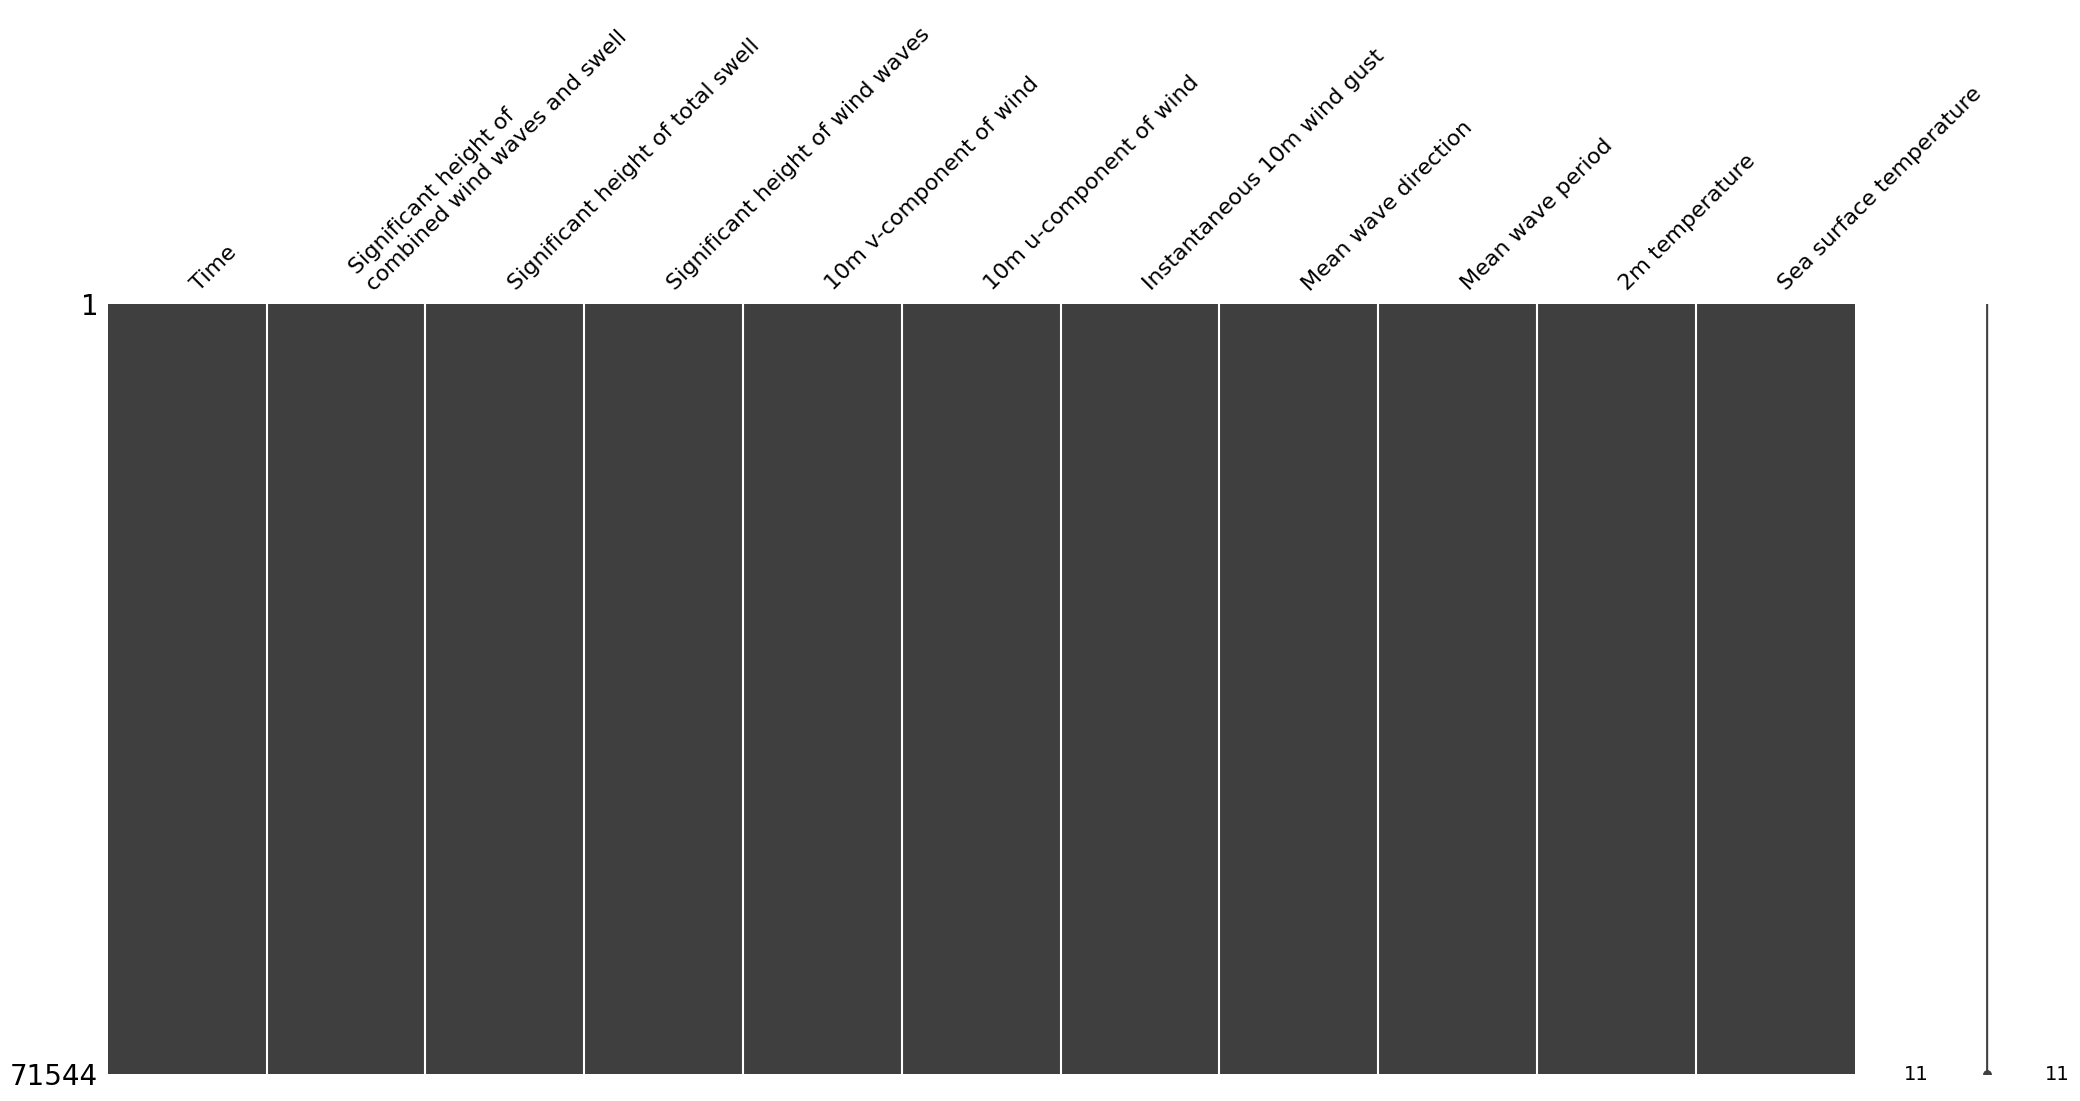

In [ ]:
import missingno as msno
msno.matrix(PaTongPhuket)

In [ ]:
import matplotlib.pyplot as plt
import missingno as msno
import os

# Ensure Google Drive is mounted
from google.colab import drive
drive.mount('/content/drive/', force_remount=True)

# Create the missingno matrix plot
fig = msno.matrix(PaTongPhuket)

# Define the path to save the plot in Google Drive
output_path = '/content/drive/MyDrive/missingno_patong_matrix.png'

# Save the figure
fig_obj = fig.get_figure() # Get the actual figure object from the Axes returned by msno.matrix
fig_obj.savefig(output_path, bbox_inches='tight')

print(f"Missingno matrix plot saved to: {output_path}")

# Close the plot to prevent it from displaying in the notebook if not desired
plt.close(fig_obj)

Mounted at /content/drive/
Missingno matrix plot saved to: /content/drive/MyDrive/missingno_patong_matrix.png


In [ ]:
# Check for missing values
missing_values = PaTongPhuket.isnull().sum()
display("Missing values in each column:")
display(missing_values)

# Display concise summary of the DataFrame, including the number of non-null entries
display(PaTongPhuket.info())

'Missing values in each column:'

,0
Time,0
Significant height of\ncombined wind waves and swell,0
Significant height of total swell,0
Significant height of wind waves,0
10m v-component of wind,0
10m u-component of wind,0
Instantaneous 10m wind gust,0
Mean wave direction,0
Mean wave period,0
2m temperature,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71544 entries, 0 to 71543
Data columns (total 11 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   Time                                                 71544 non-null  object 
 1   Significant height of
combined wind waves and swell  71544 non-null  float64
 2   Significant height of total swell                    71544 non-null  float64
 3   Significant height of wind waves                     71544 non-null  float64
 4   10m v-component of wind                              71544 non-null  float64
 5   10m u-component of wind                              71544 non-null  float64
 6   Instantaneous 10m wind gust                          71544 non-null  float64
 7   Mean wave direction                                  71544 non-null  float64
 8   Mean wave period                                     71544 non-nul

None

คอลัมน์ทั้ง 8 คอลัมน์ ไม่มีค่าที่หายไป

In [9]:
# กำหนดให้คอลัมน์ 'Time' เป็น Index ของ DataFrame และแปลงเป็น DatetimeIndex
# ก่อนอื่น ทำความสะอาดคอลัมน์ 'Time' โดยการลบช่องว่างนำหน้าและตามหลัง
PaTongPhuket['Time'] = PaTongPhuket['Time'].str.strip()

# สร้างฟังก์ชันเพื่อทำให้รูปแบบเวลาเป็นมาตรฐาน โดยเปลี่ยน 'HH.MM' เป็น 'HH:MM'
def standardize_time_separator(time_str):
    if isinstance(time_str, str):
        parts = time_str.split(' ')
        if len(parts) == 2:
            date_part, time_part = parts
            if '.' in time_part: # ตรวจสอบว่ามีจุดในส่วนของเวลาหรือไม่
                time_part = time_part.replace('.', ':')
            return f"{date_part} {time_part}"
    return time_str # คืนค่าเดิมหากไม่ใช่ string หรือรูปแบบไม่ตรงกัน

PaTongPhuket['Time'] = PaTongPhuket['Time'].apply(standardize_time_separator)

PaTongPhuket_indexed = PaTongPhuket.set_index('Time')
# เมื่อทำรูปแบบเวลาเป็นมาตรฐานแล้ว สามารถใช้ format ที่แน่นอนได้
PaTongPhuket_indexed.index = pd.to_datetime(PaTongPhuket_indexed.index, format='%d/%m/%Y %H:%M')

# แสดงข้อความและ 5 แถวแรกของ DataFrame เพื่อให้เห็นว่าคอลัมน์ 'Time' ได้กลายเป็น Index
display("DataFrame with 'Time' as datetime index:")
display(PaTongPhuket_indexed.head())

# แสดงชนิดข้อมูลของแต่ละคอลัมน์
display("Data types including index type:")
display(PaTongPhuket_indexed.dtypes)

"DataFrame with 'Time' as datetime index:"

,Significant height of\ncombined wind waves and swell,Significant height of total swell,Significant height of wind waves,10m v-component of wind,10m u-component of wind,Instantaneous 10m wind gust,Mean wave direction,Mean wave period,2m temperature,Sea surface temperature
Time,,,,,,,,,,
2018-01-01 00:00:00,0.819530,0.512232,0.596436,-5.857641,-1.347422,8.788392,93.266464,4.970300,299.608520,301.705241
2018-01-01 01:00:00,0.806473,0.516237,0.576659,-5.828161,-1.395849,8.524141,94.748993,5.006505,299.633402,301.705241
2018-01-01 02:00:00,0.789961,0.513183,0.559022,-5.819311,-1.313538,8.112156,95.893707,5.018085,299.714030,301.705241
2018-01-01 03:00:00,0.773173,0.509671,0.538153,-5.572749,-0.925797,7.469082,97.431259,5.024179,299.766561,301.705241
2018-01-01 04:00:00,0.752750,0.576924,0.464689,-5.283966,-0.376038,6.867215,99.879059,5.049937,299.849436,301.705241


'Data types including index type:'

,0
Significant height of\ncombined wind waves and swell,float64
Significant height of total swell,float64
Significant height of wind waves,float64
10m v-component of wind,float64
10m u-component of wind,float64
Instantaneous 10m wind gust,float64
Mean wave direction,float64
Mean wave period,float64
2m temperature,float64
Sea surface temperature,float64


In [ ]:
# ตรวจสอบ time difference ระหว่างแถวที่ติดกัน
time_diff = PaTongPhuket_indexed.index.to_series().diff().dropna()

# สร้างเวกเตอร์ของ time difference
time_diff_vector = time_diff.values

# ตรวจสอบว่า time difference ทั้งหมดเท่ากับ 1 ชั่วโมงหรือไม่
# เนื่องจาก time_diff เป็น TimedeltaIndex, เราสามารถเปรียบเทียบกับ pd.Timedelta(hours=1)
is_one_hour = (time_diff == pd.Timedelta(hours=1))

# ตรวจสอบว่ามีค่าใดที่ไม่เท่ากับ 1 ชั่วโมงหรือไม่
if not is_one_hour.all():
    display("พบความแตกต่างของเวลาที่ไม่เท่ากับ 1 ชั่วโมง:")
    display(time_diff[~is_one_hour])
else:
    display("ความแตกต่างของเวลาในแต่ละแถวเท่ากับ 1 ชั่วโมงทั้งหมด")

    display("ตารางแสดงความแตกต่างของเวลาในแต่ละแถว:")
display(time_diff.head())
display("...")
display(time_diff.tail())

'ความแตกต่างของเวลาในแต่ละแถวเท่ากับ 1 ชั่วโมงทั้งหมด'

'ตารางแสดงความแตกต่างของเวลาในแต่ละแถว:'

,Time
Time,
2018-01-01 01:00:00,0 days 01:00:00
2018-01-01 02:00:00,0 days 01:00:00
2018-01-01 03:00:00,0 days 01:00:00
2018-01-01 04:00:00,0 days 01:00:00
2018-01-01 05:00:00,0 days 01:00:00


'...'

,Time
Time,
2026-02-28 19:00:00,0 days 01:00:00
2026-02-28 20:00:00,0 days 01:00:00
2026-02-28 21:00:00,0 days 01:00:00
2026-02-28 22:00:00,0 days 01:00:00
2026-02-28 23:00:00,0 days 01:00:00


In [ ]:
# Check for duplicate rows
duplicate_rows = PaTongPhuket[PaTongPhuket.duplicated()]

if duplicate_rows.empty:
    display("ไม่มีแถวที่ซ้ำกันในข้อมูล")
else:
    display("พบแถวที่ซ้ำกันในข้อมูล:")
    display(duplicate_rows)

'ไม่มีแถวที่ซ้ำกันในข้อมูล'

In [ ]:
# ตรวจสอบว่ามี "เวลา" (ซึ่งเป็น Index) ซ้ำซ้อนกันหรือไม่
index_duplicates = PaTongPhuket_indexed.index.duplicated()

if not index_duplicates.any():
    display("ไม่พบแถวข้อมูลที่มี 'เวลาซ้ำซ้อน' (Unique Timestamps)")
    display("ทุกจุดเวลาในชุดข้อมูลนี้มีข้อมูลเพียงชุดเดียว")
else:
    display("พบแถวข้อมูลที่มี 'เวลาซ้ำซ้อน' (Duplicate Timestamps)!")

    # แสดงให้เห็นว่าเวลาไหนที่ซ้ำ
    duplicate_times = PaTongPhuket_indexed.index[index_duplicates].unique()
    display(f"พบเวลาที่ซ้ำซ้อนกัน {len(duplicate_times)} จุดเวลา:")
    display(duplicate_times)

    # แสดงแถวที่ซ้ำทั้งหมด (ทั้งแถวเก่าและแถวใหม่ที่ซ้ำกัน)
    display("แถวข้อมูลทั้งหมดที่มีเวลาซ้ำซ้อนกัน:")
    display(PaTongPhuket_indexed[PaTongPhuket_indexed.index.duplicated(keep=False)])

"ไม่พบแถวข้อมูลที่มี 'เวลาซ้ำซ้อน' (Unique Timestamps)"

'ทุกจุดเวลาในชุดข้อมูลนี้มีข้อมูลเพียงชุดเดียว'

# สำรวจและวิเคราะห์ข้อมูลเบื้องต้น (Exploratory Data Analysis - EDA)

In [10]:
# Display basic descriptive statistics
display("Basic descriptive statistics for the DataFrame:")
display(PaTongPhuket_indexed.describe())

'Basic descriptive statistics for the DataFrame:'

,Significant height of\ncombined wind waves and swell,Significant height of total swell,Significant height of wind waves,10m v-component of wind,10m u-component of wind,Instantaneous 10m wind gust,Mean wave direction,Mean wave period,2m temperature,Sea surface temperature
count,71544.000000,71544.000000,7.154400e+04,71544.000000,71544.000000,71544.000000,71544.000000,71544.000000,71544.000000,71544.000000
mean,0.804174,0.688629,3.055382e-01,0.571893,-0.252694,6.681154,224.891788,6.616186,300.933829,302.598362
std,0.361488,0.291571,3.319631e-01,4.309138,2.223530,2.812756,67.369956,1.460895,0.915281,0.613116
min,0.224408,0.150635,2.480000e-16,-10.984273,-10.138977,1.267763,0.385783,3.346094,297.800741,301.085612
25%,0.532014,0.463285,5.969657e-02,-2.729603,-1.798654,4.503889,204.712746,5.586617,300.266759,302.147054
50%,0.711356,0.604168,1.884108e-01,0.682549,-0.315791,6.230634,249.467888,6.407051,300.936040,302.501546
75%,0.990150,0.869697,4.486866e-01,3.852262,1.250496,8.474449,259.978619,7.389547,301.587969,303.017741
max,2.695953,2.232336,2.484131e+00,12.407196,8.122823,19.241358,358.192108,15.648807,304.347534,304.618652


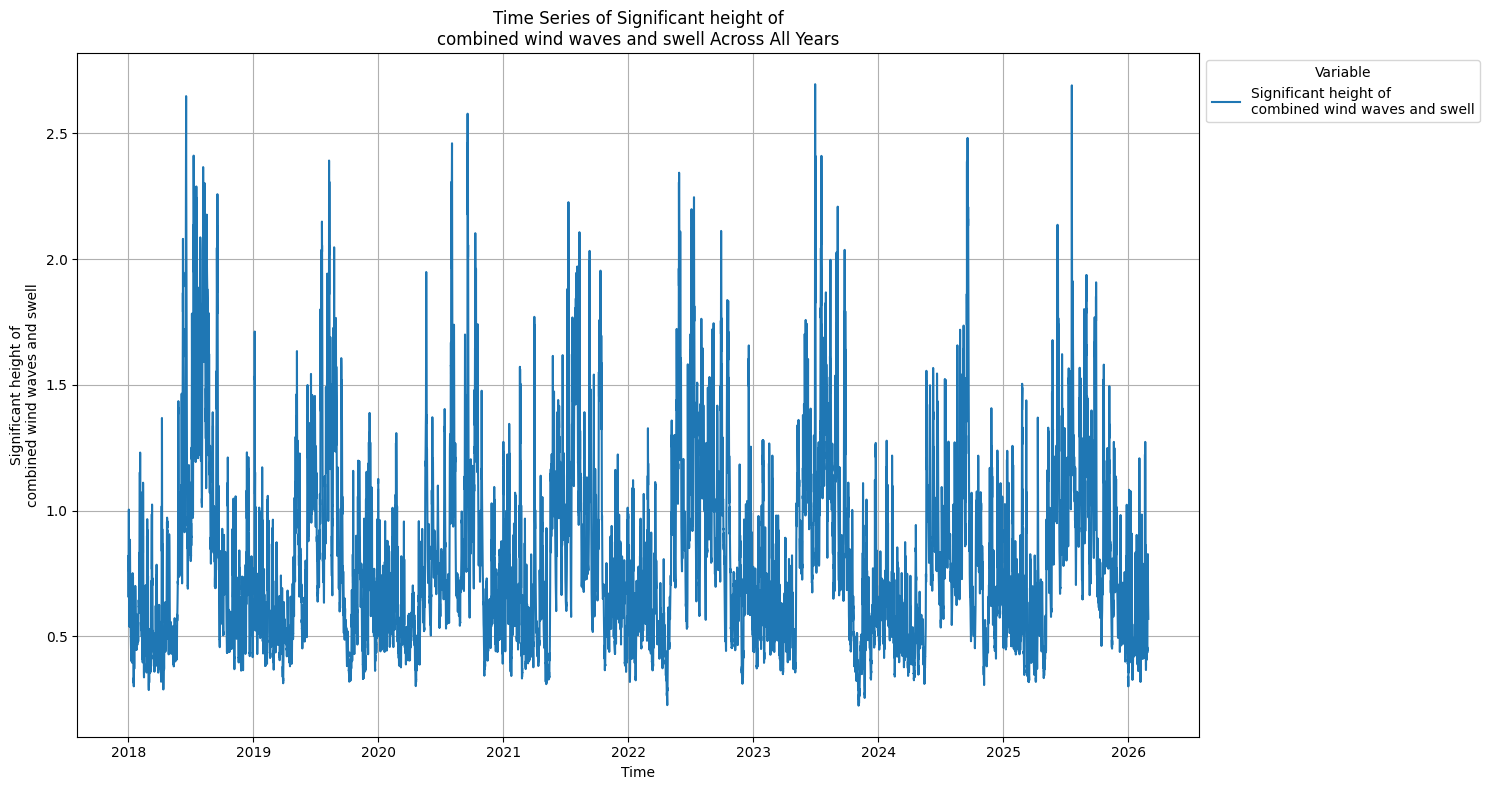

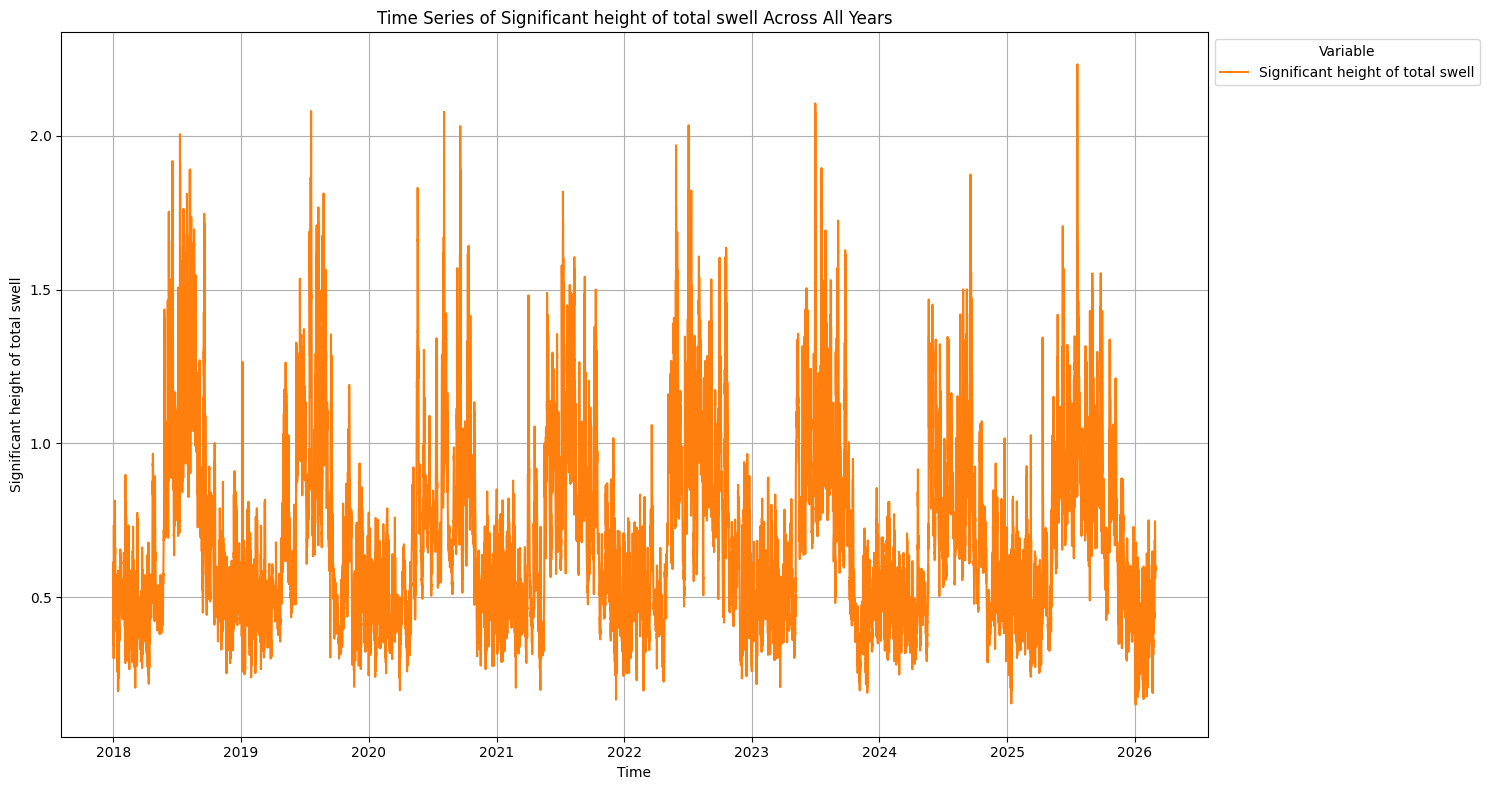

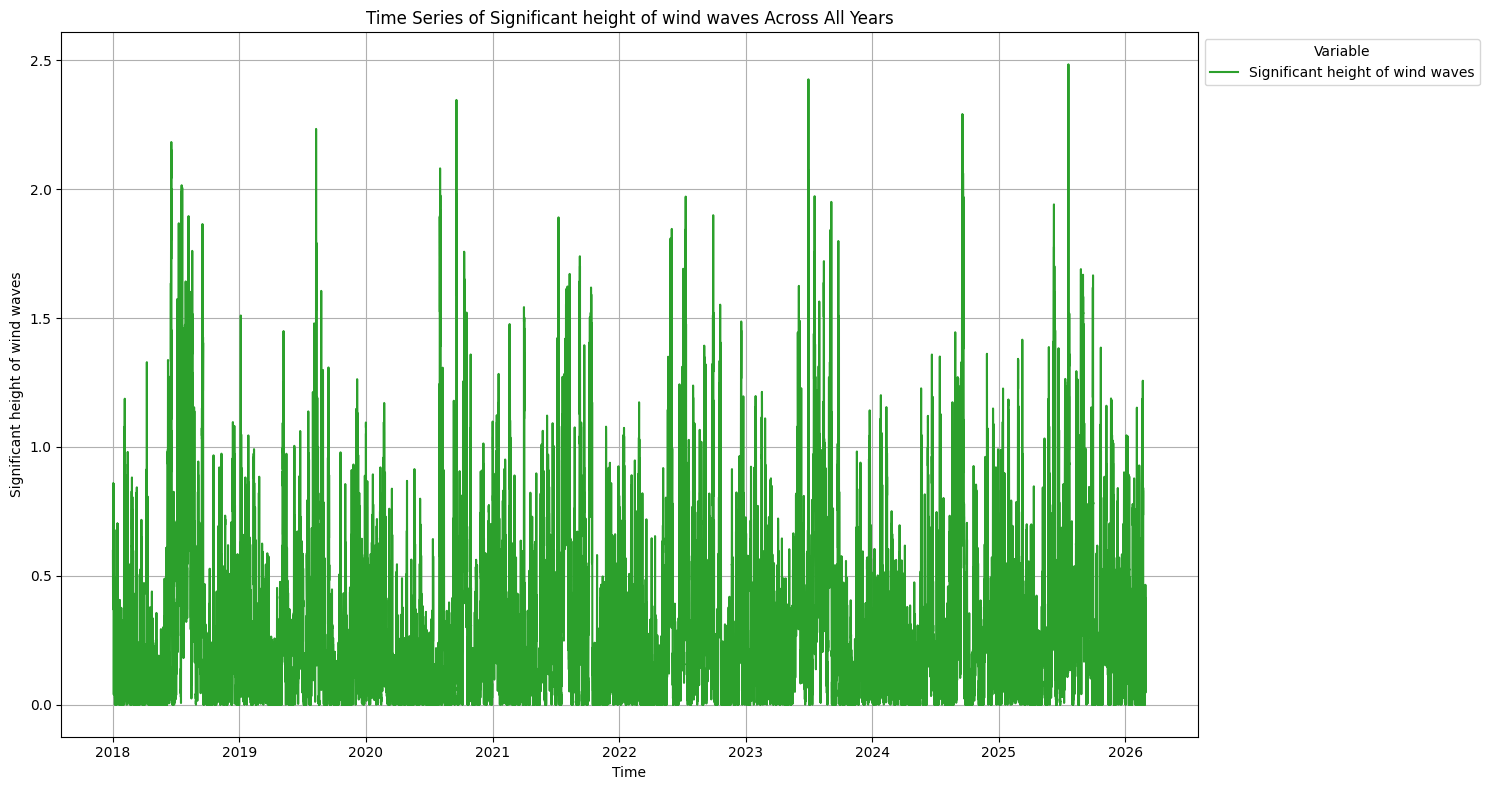

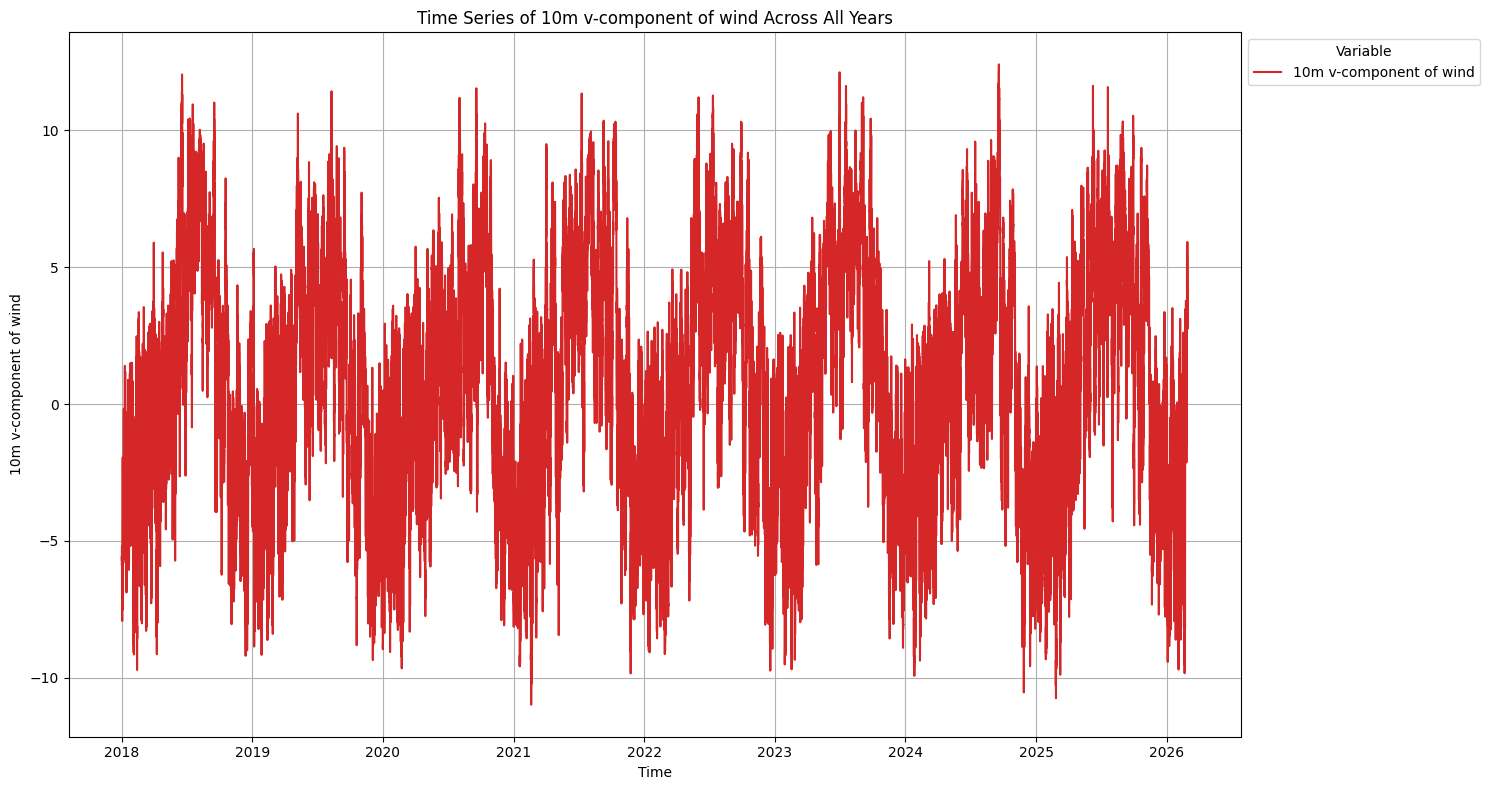

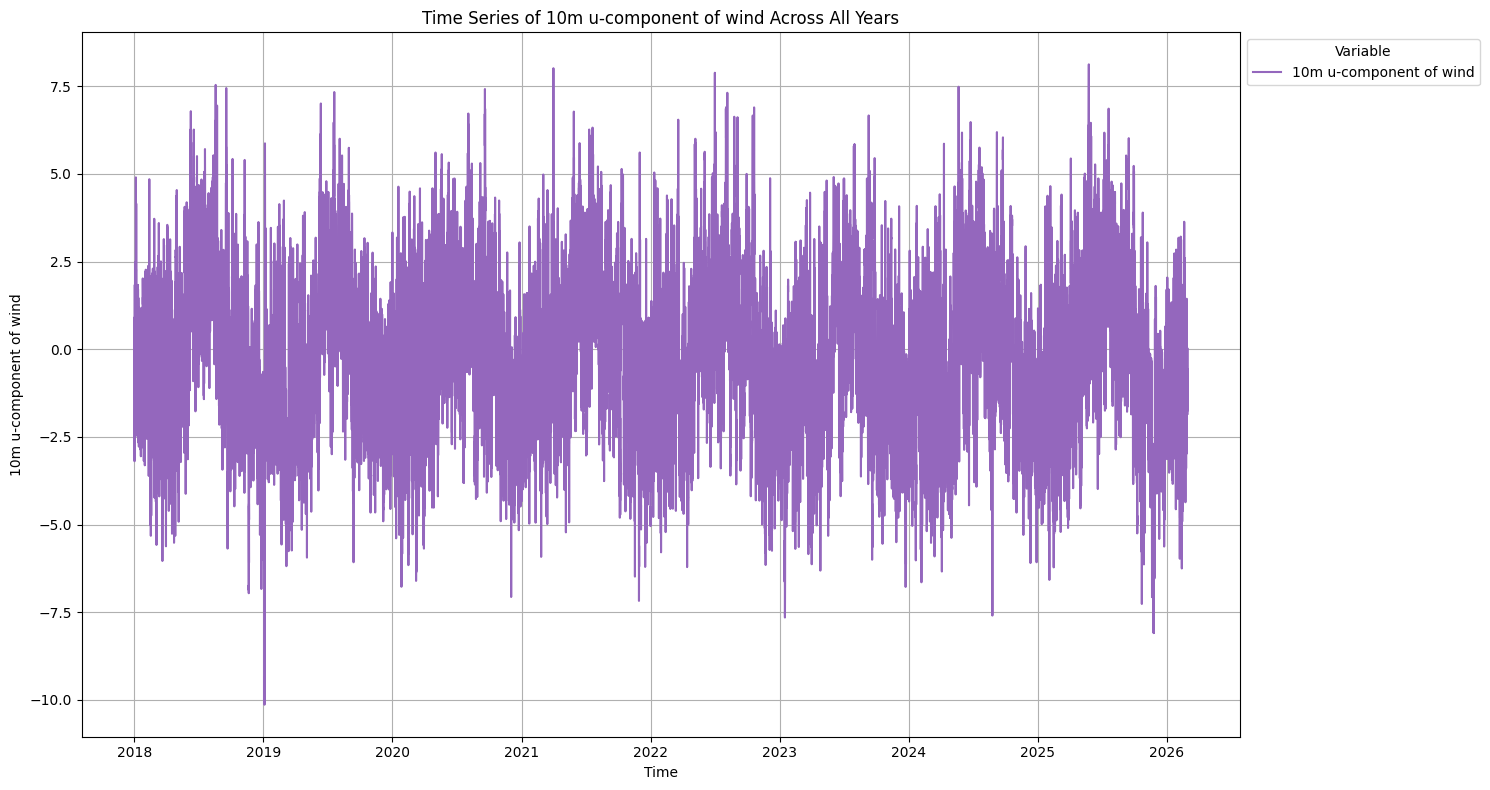

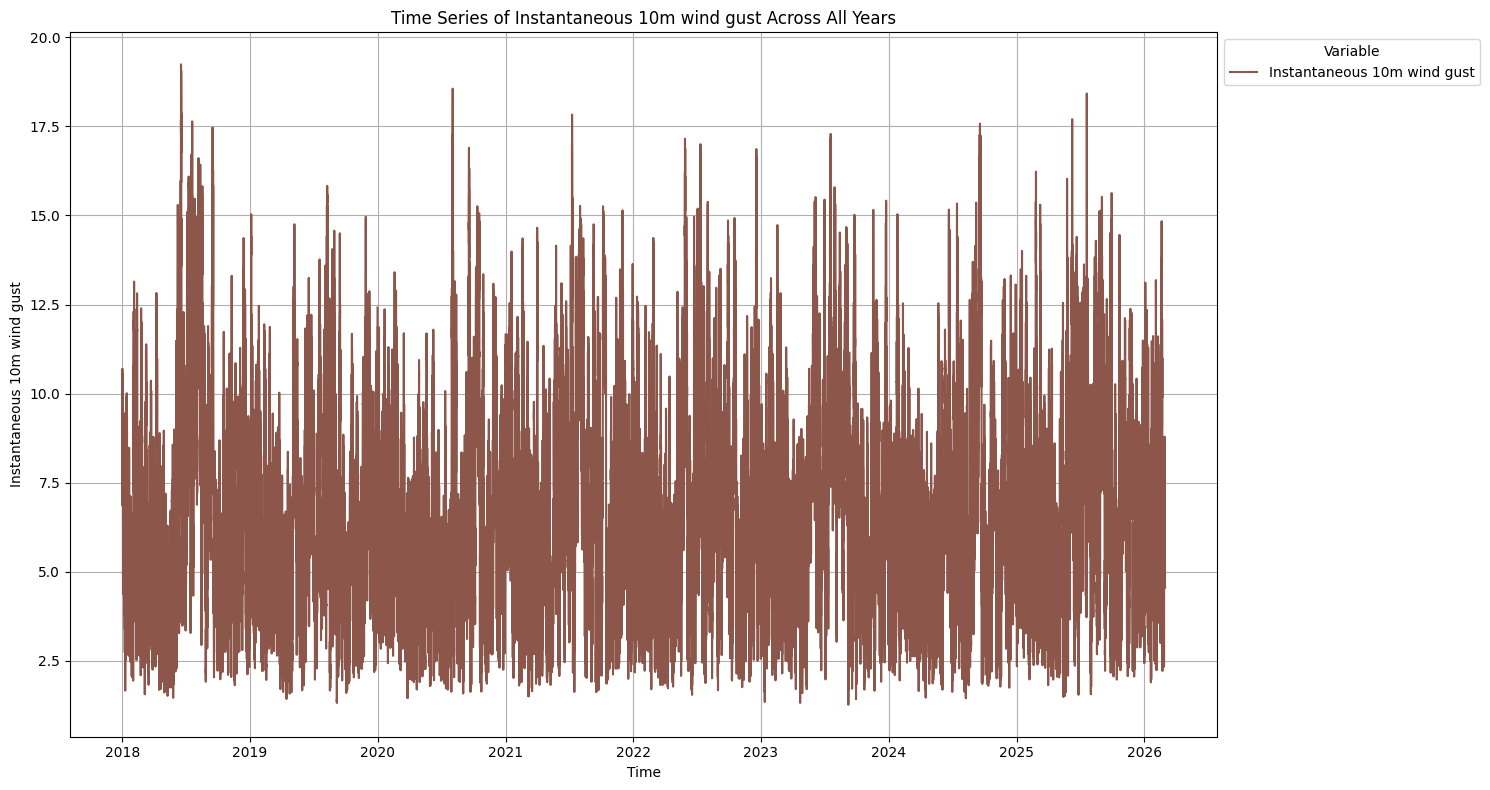

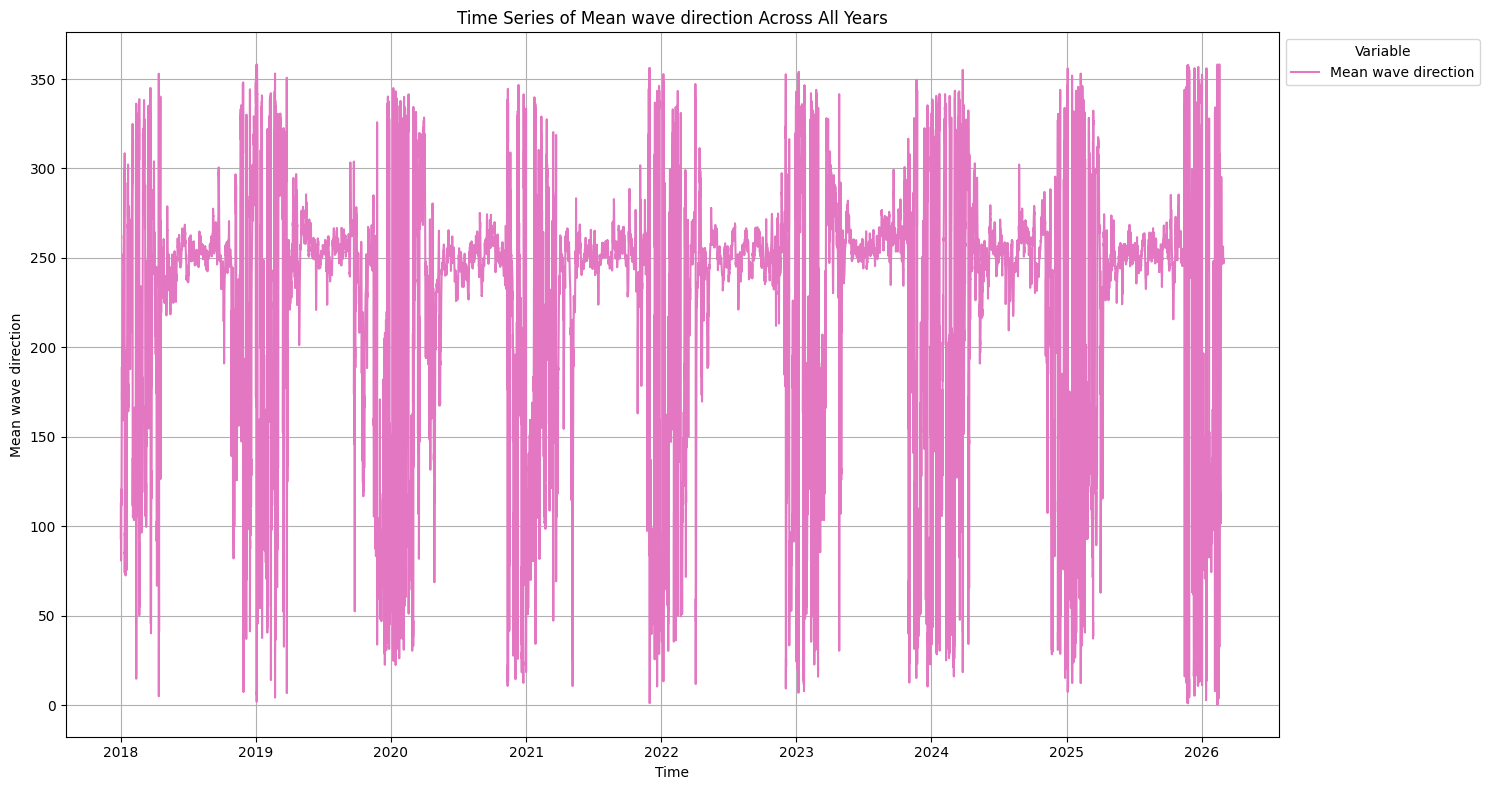

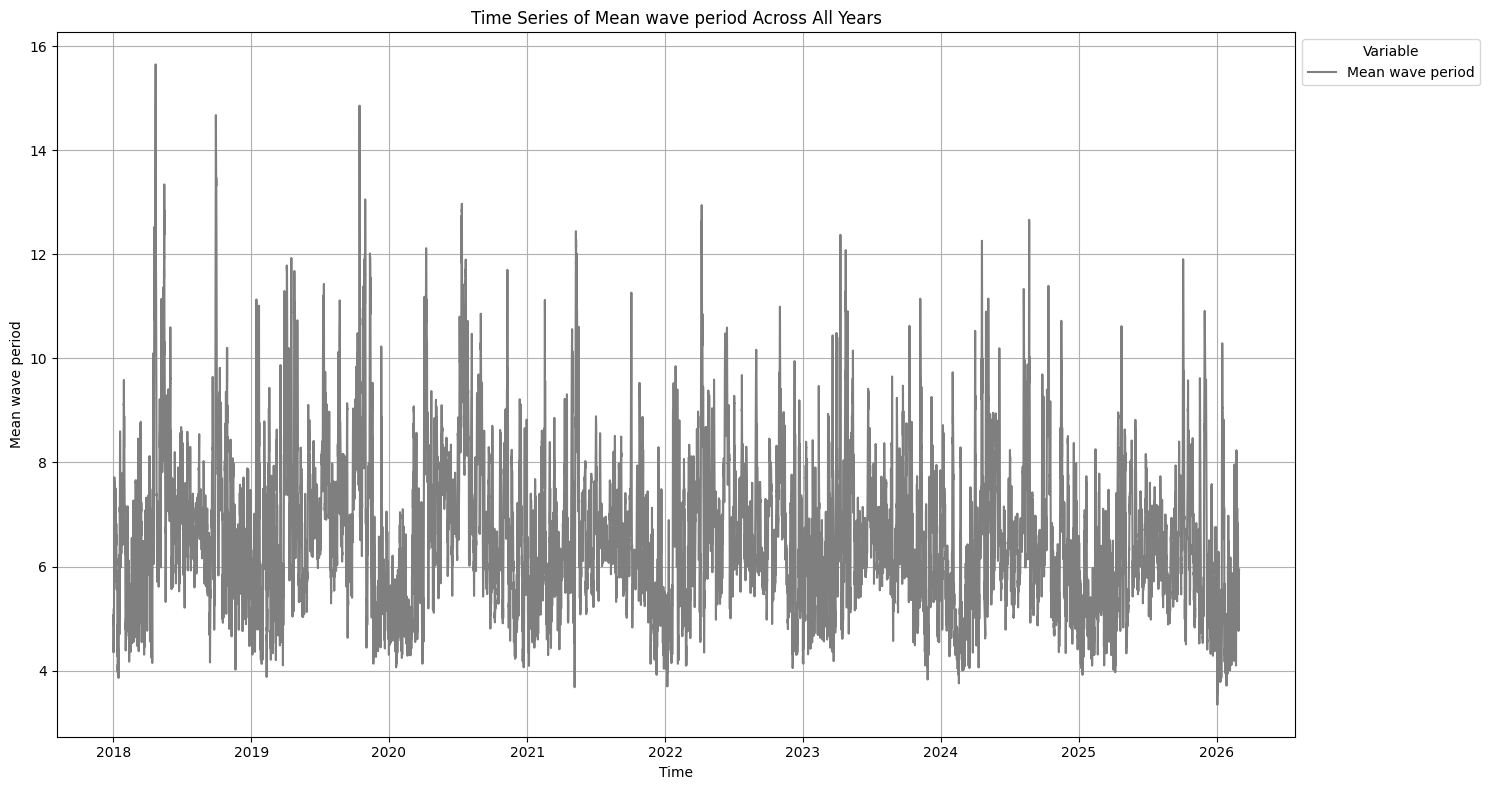

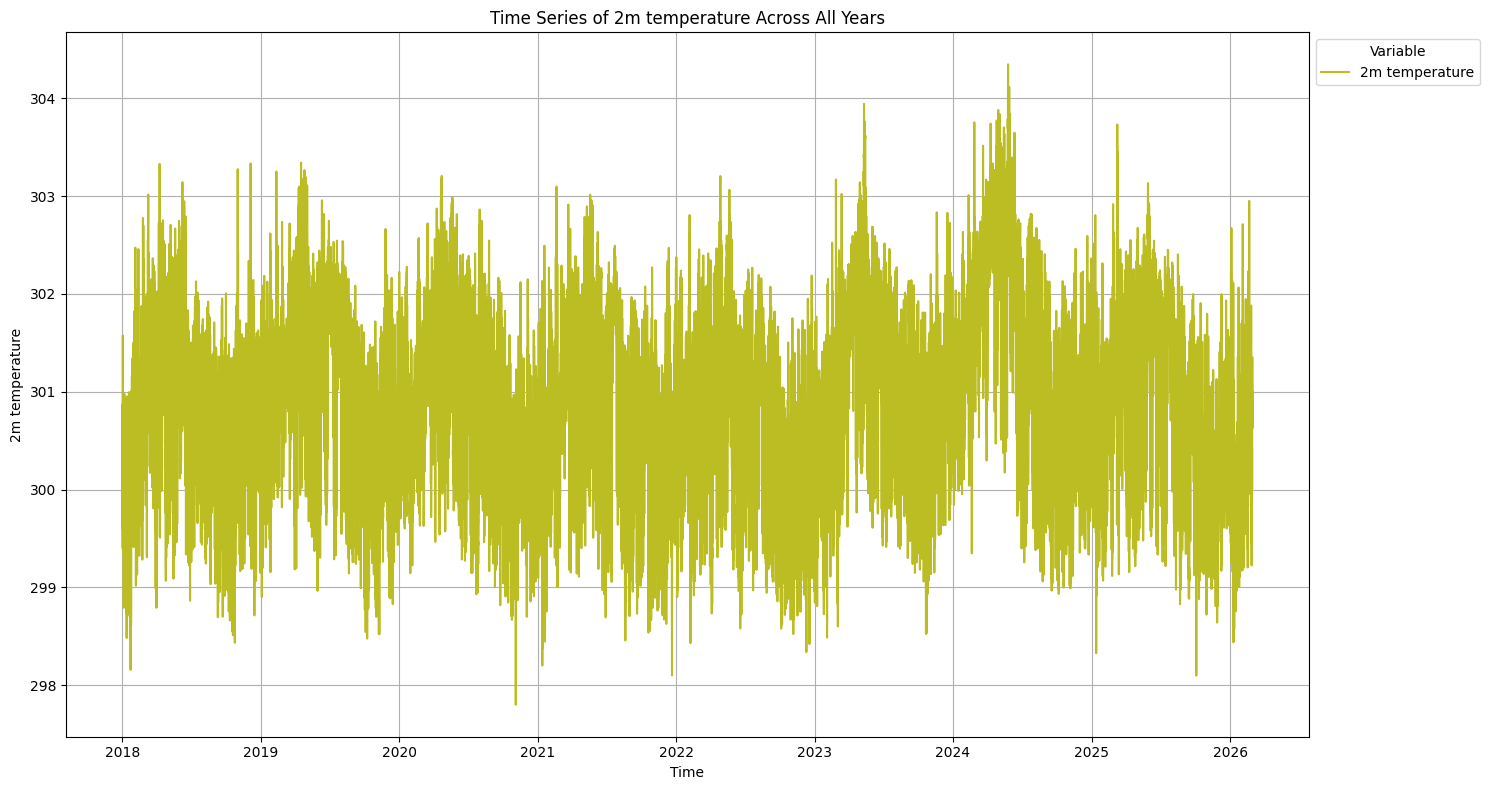

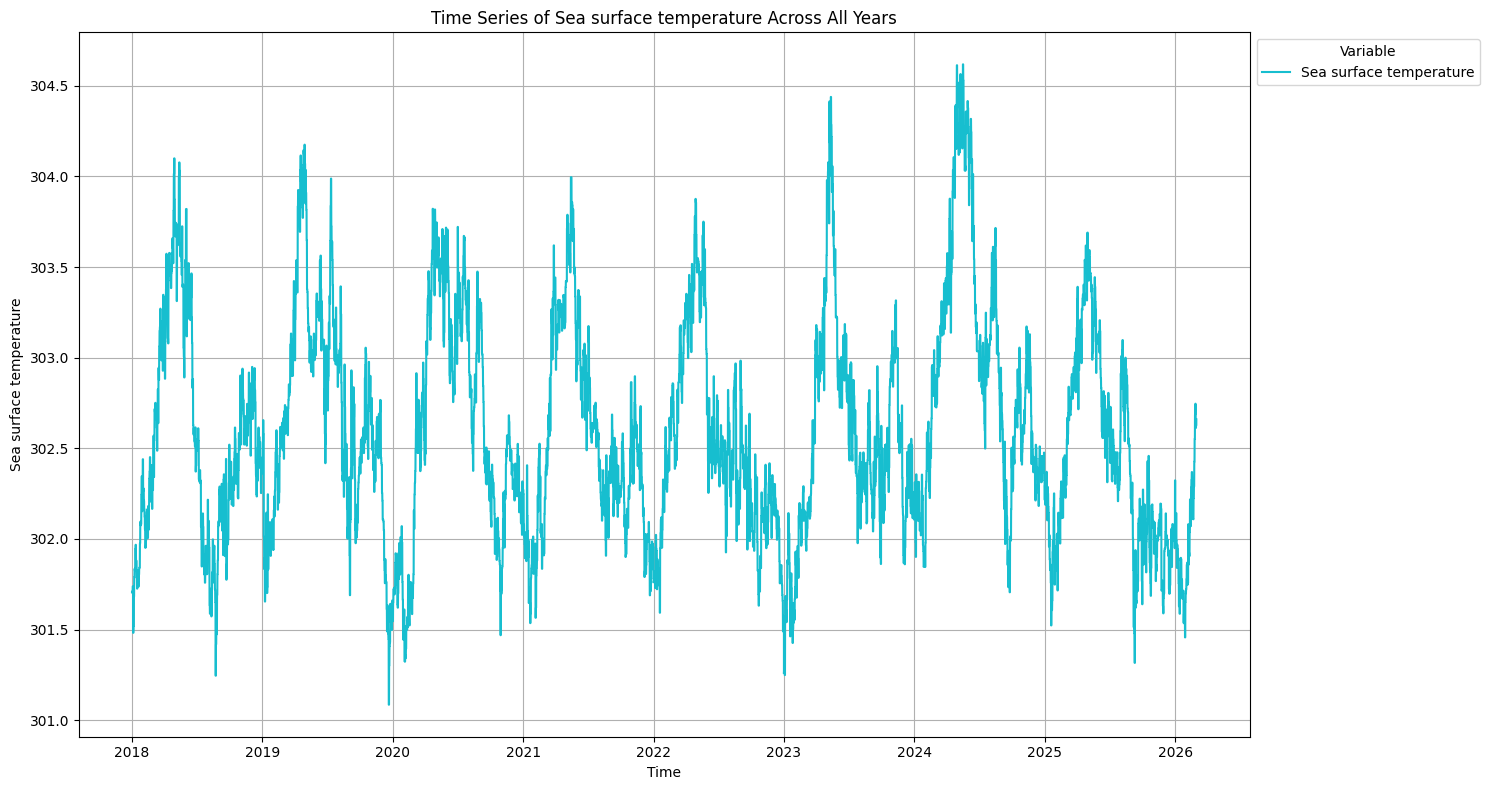

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical columns for plotting
numerical_cols = PaTongPhuket_indexed.select_dtypes(include=['float64', 'int64']).columns

# Get unique years from the index
years = PaTongPhuket_indexed.index.year.unique()

# Plot each numerical column separately, with all years in the same color
for col in numerical_cols:
    plt.figure(figsize=(15, 8))
    for year in years:
        data_yearly = PaTongPhuket_indexed[PaTongPhuket_indexed.index.year == year]
        plt.plot(data_yearly.index, data_yearly[col], color=plt.cm.tab10(numerical_cols.get_loc(col)), label=col if year == years[0] else "_nolegend_") # Use the first year's plot for the legend

    plt.title(f'Time Series of {col} Across All Years')
    plt.xlabel('Time')
    plt.ylabel(col)
    plt.legend(title='Variable', loc='upper left', bbox_to_anchor=(1, 1))
    plt.grid(True)
    plt.tight_layout()
    plt.show()

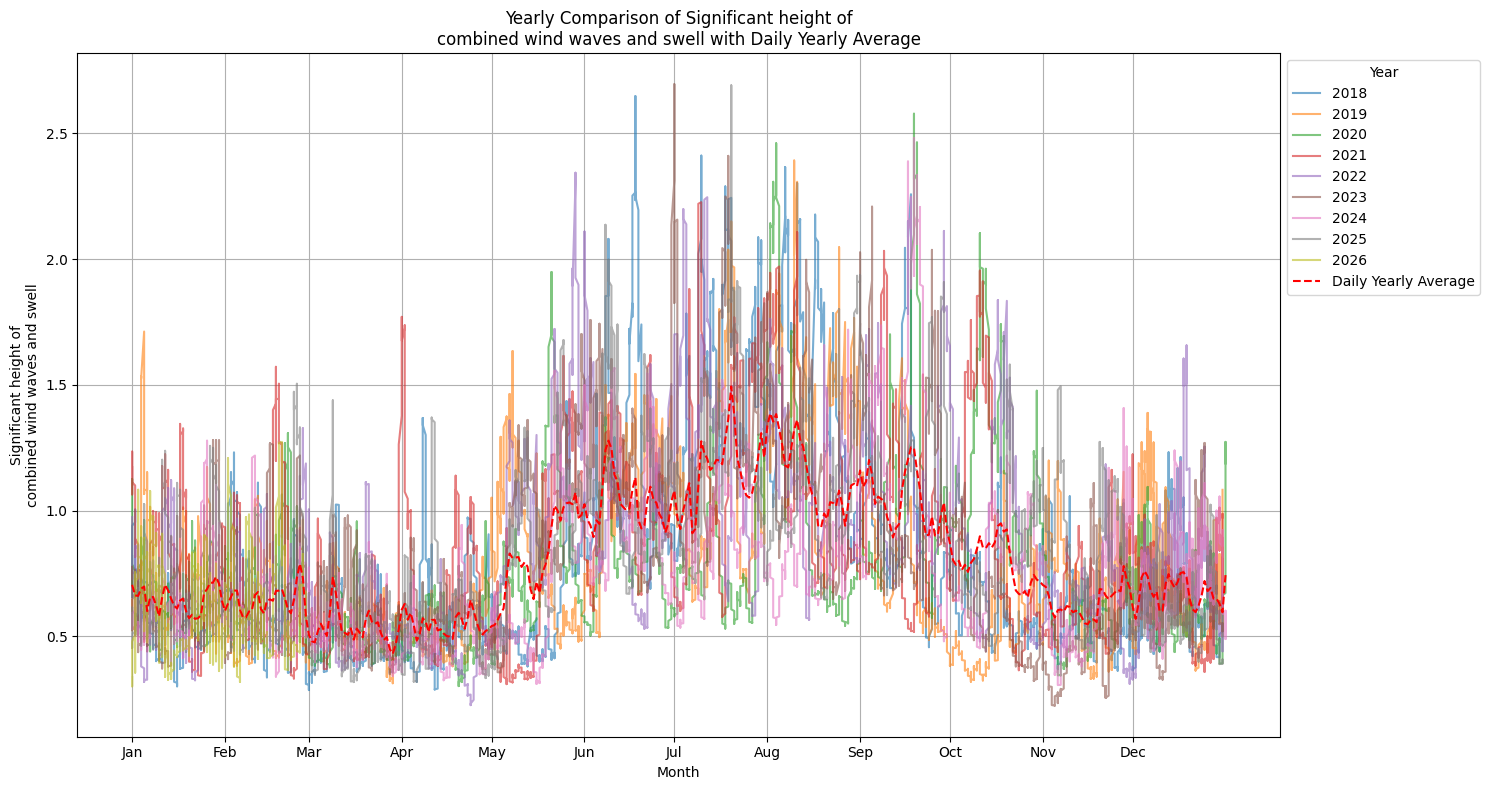

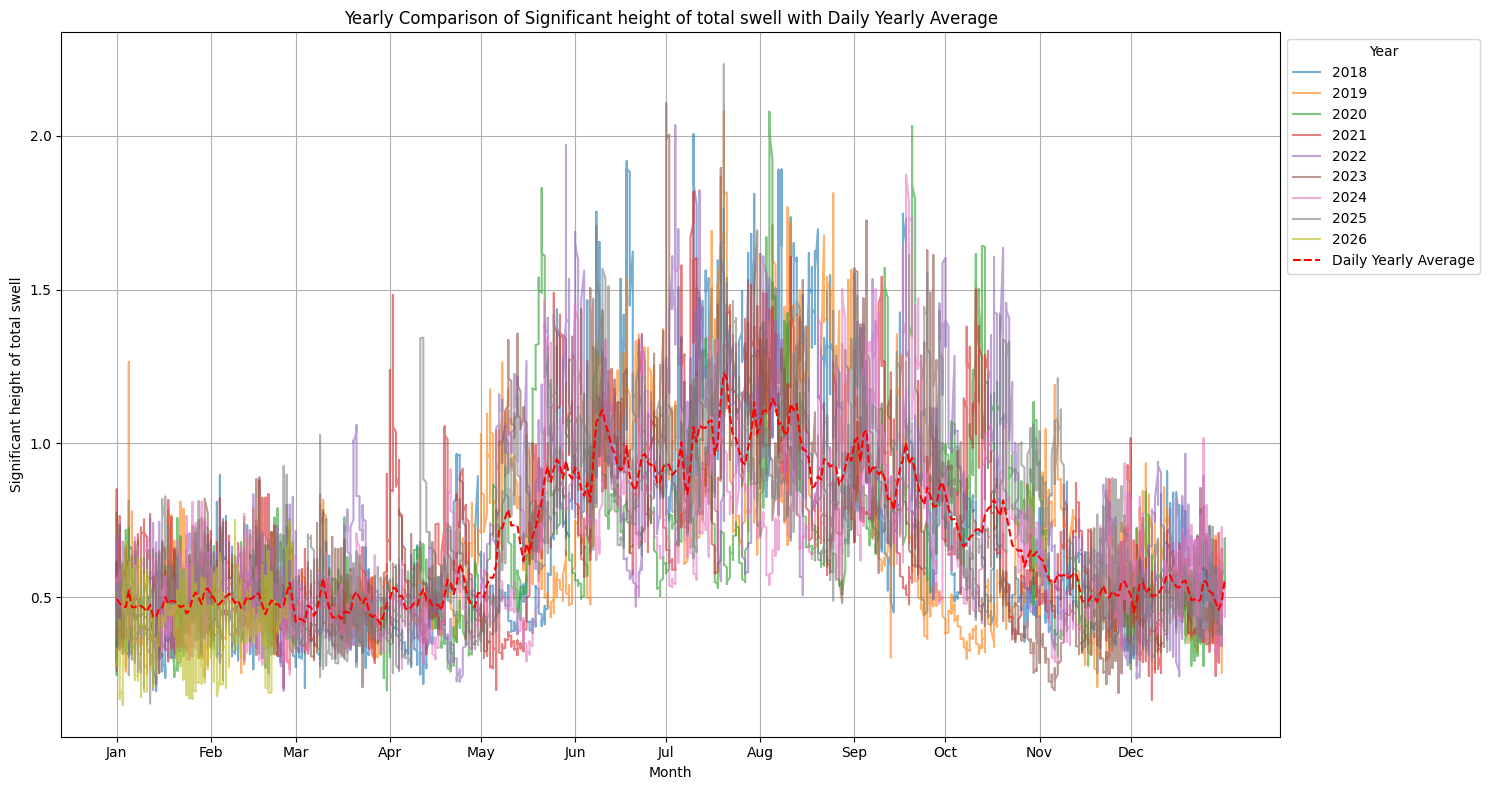

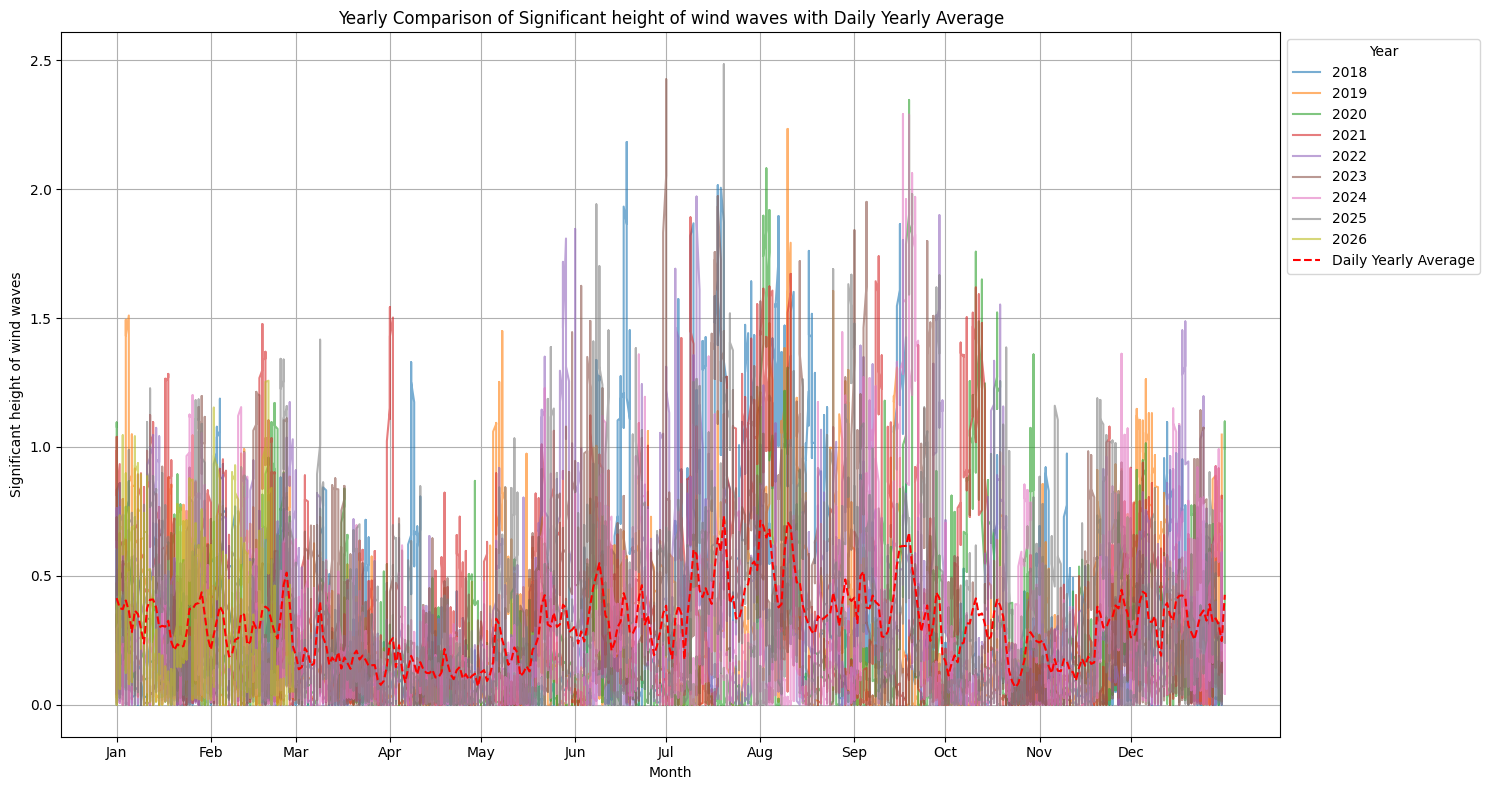

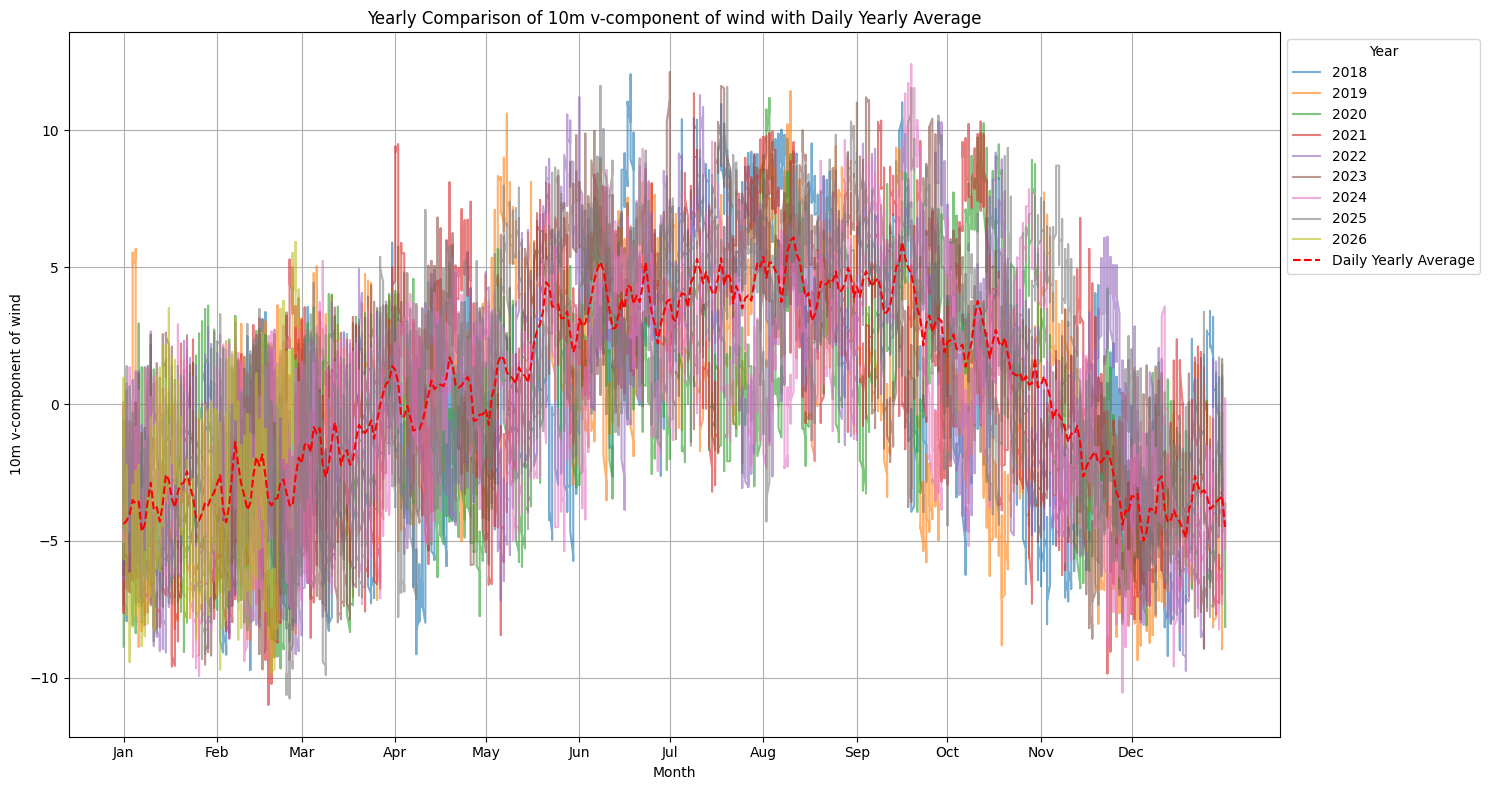

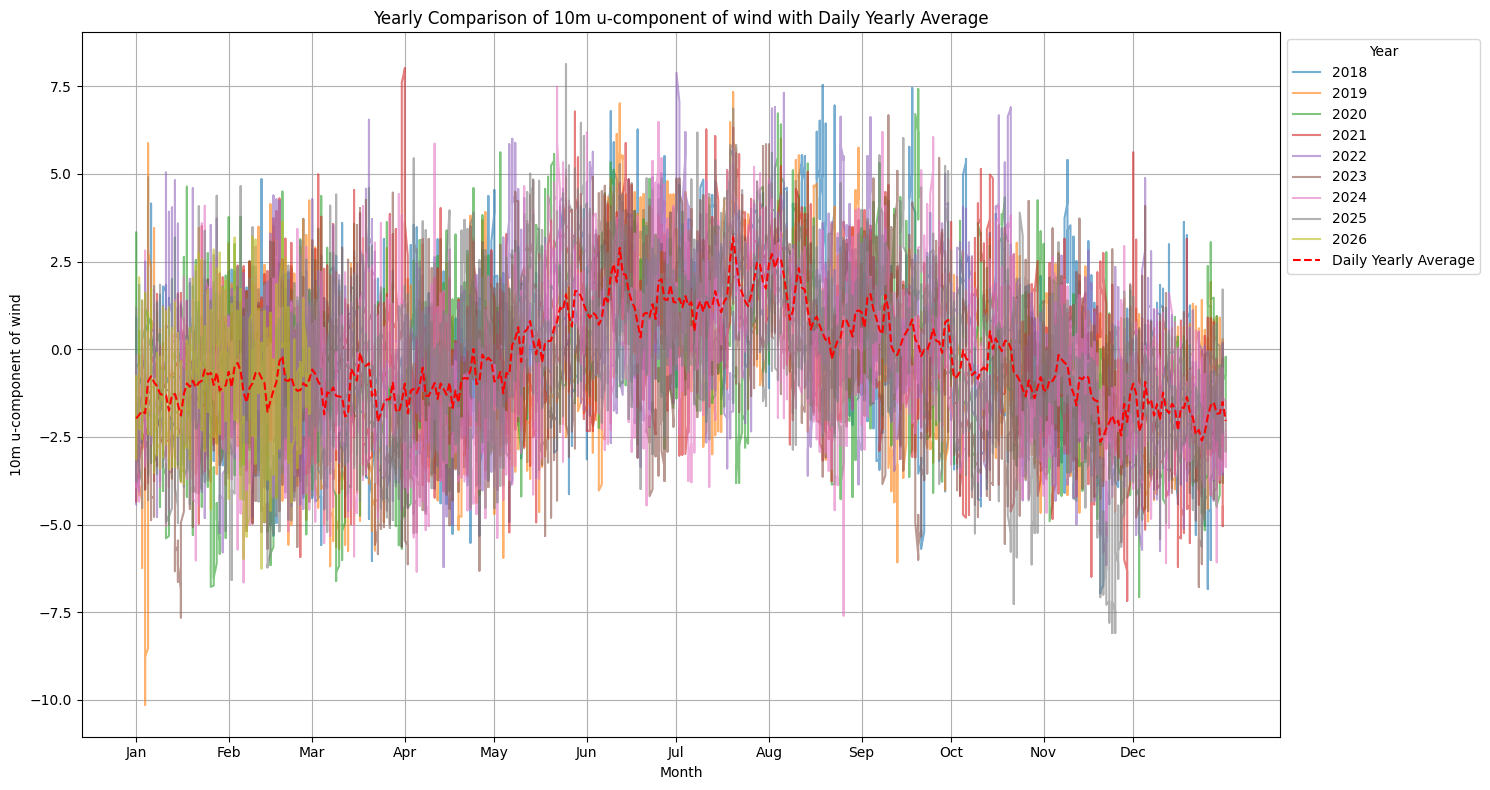

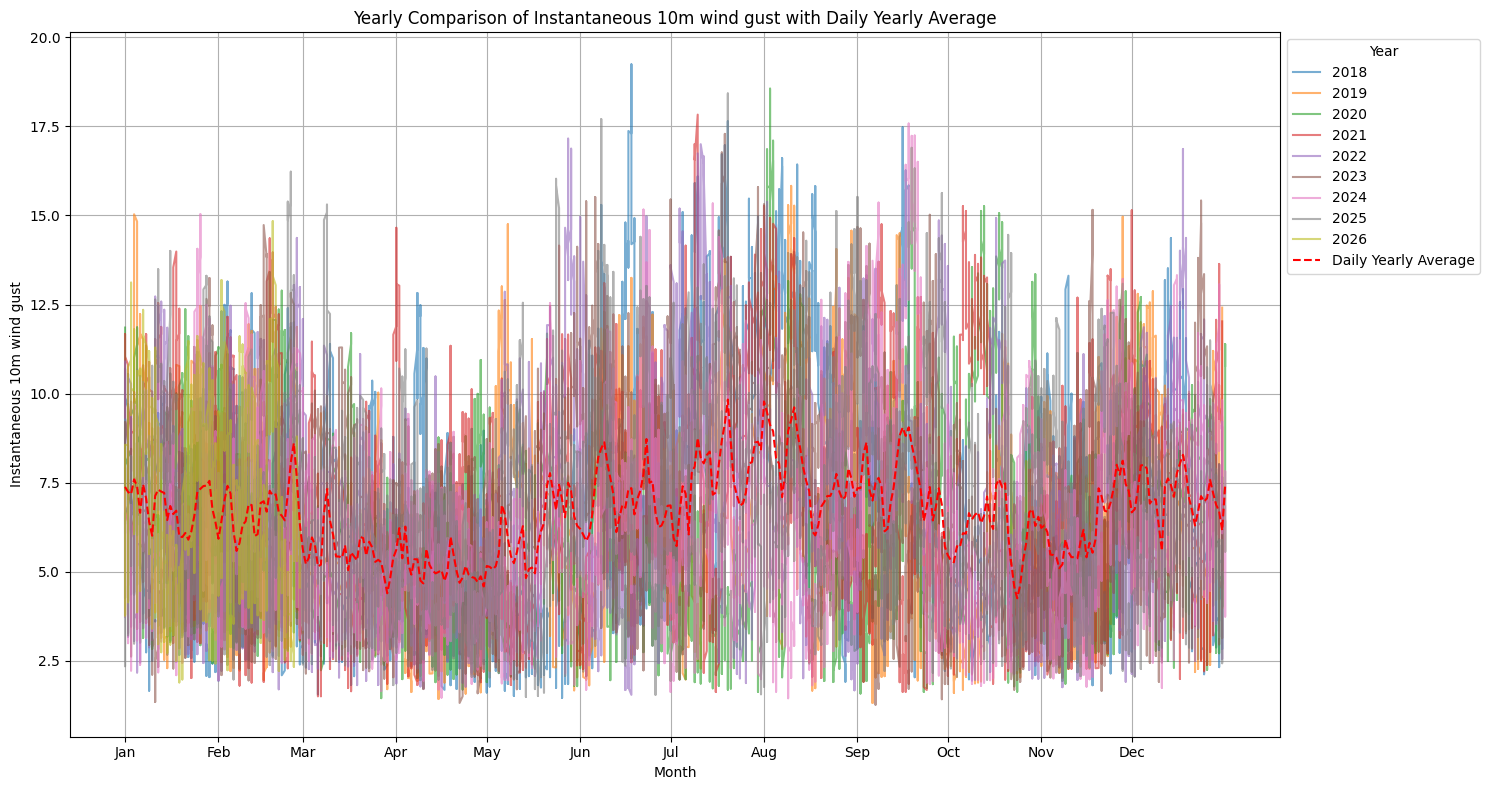

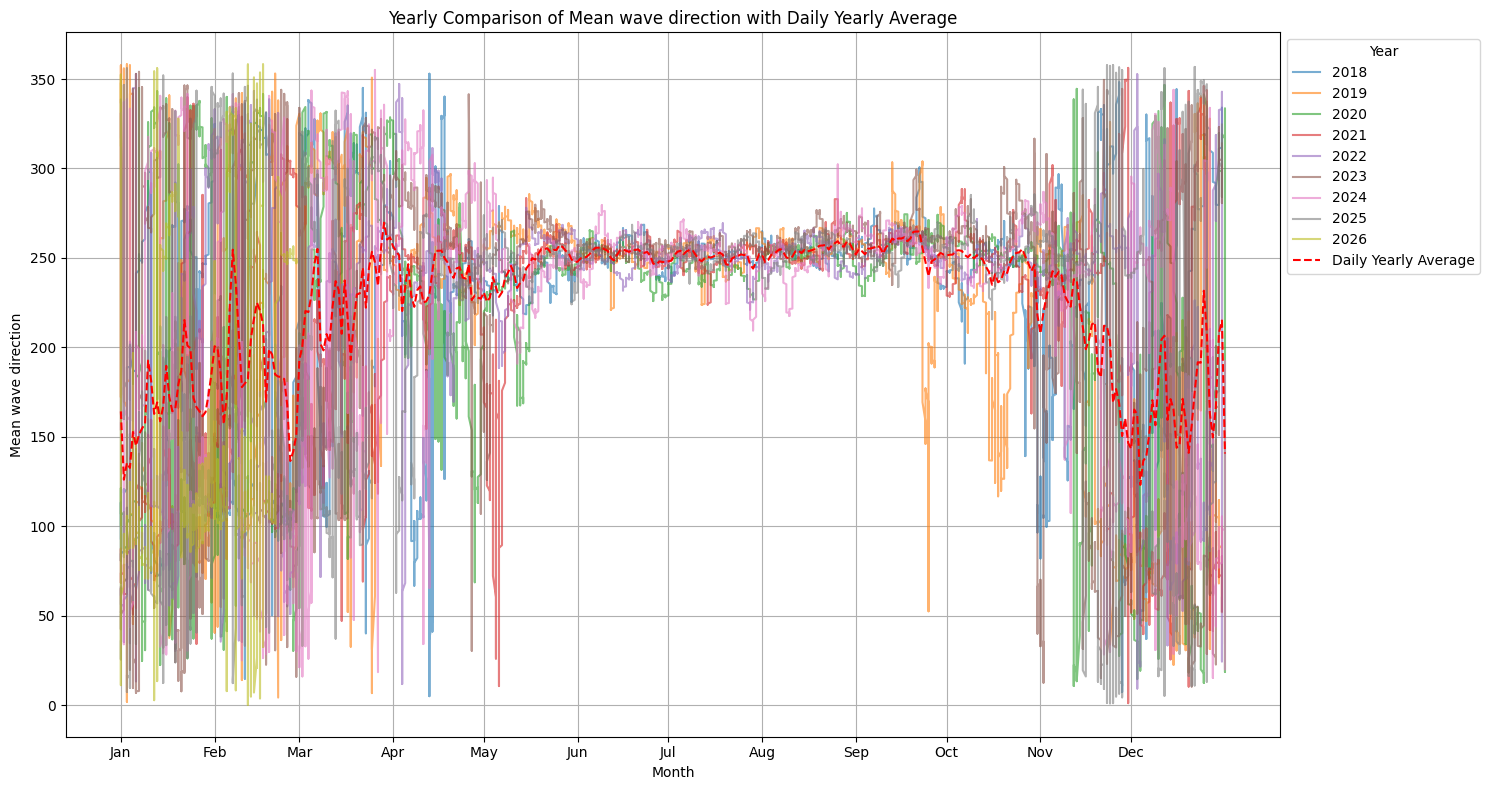

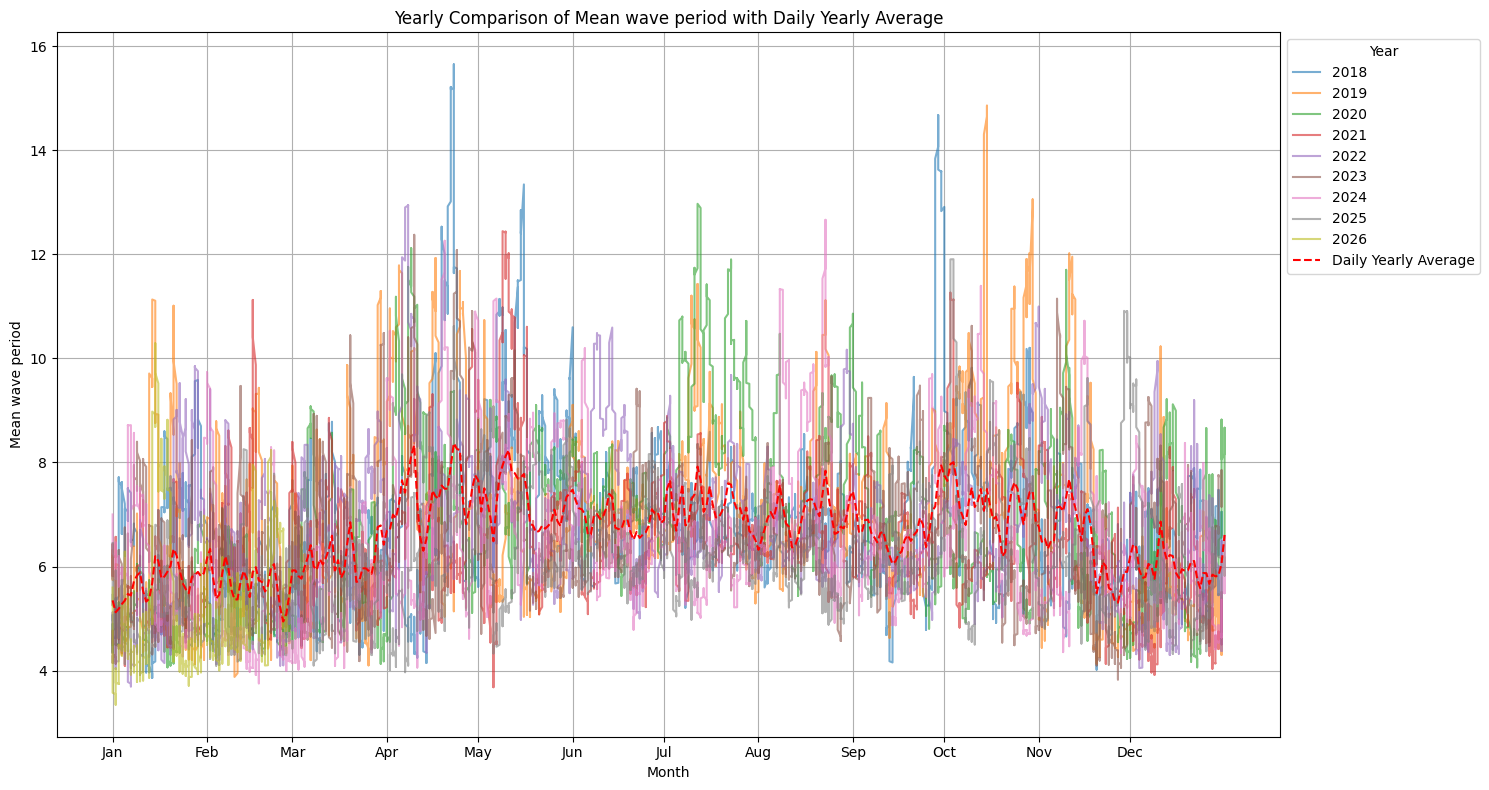

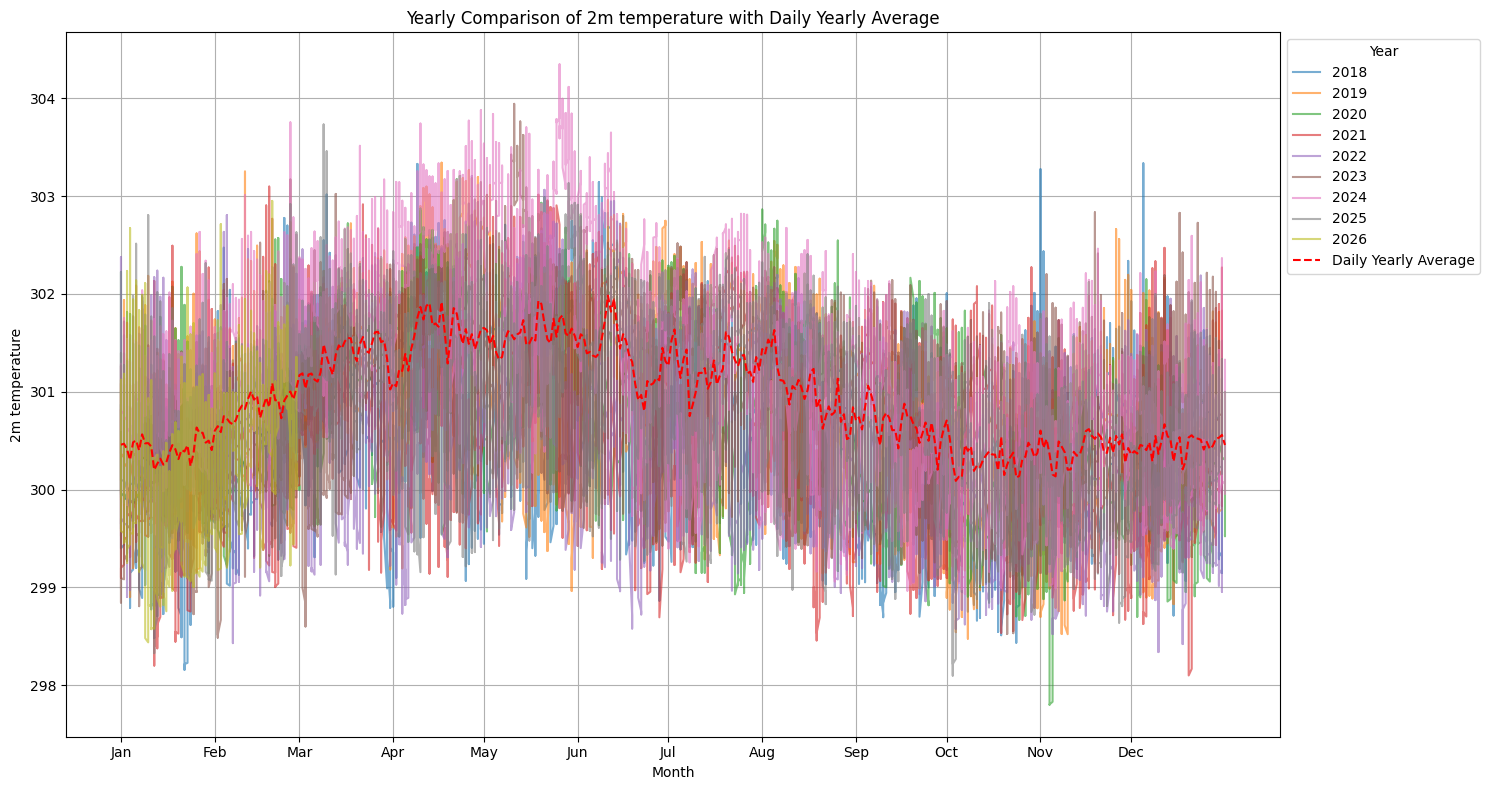

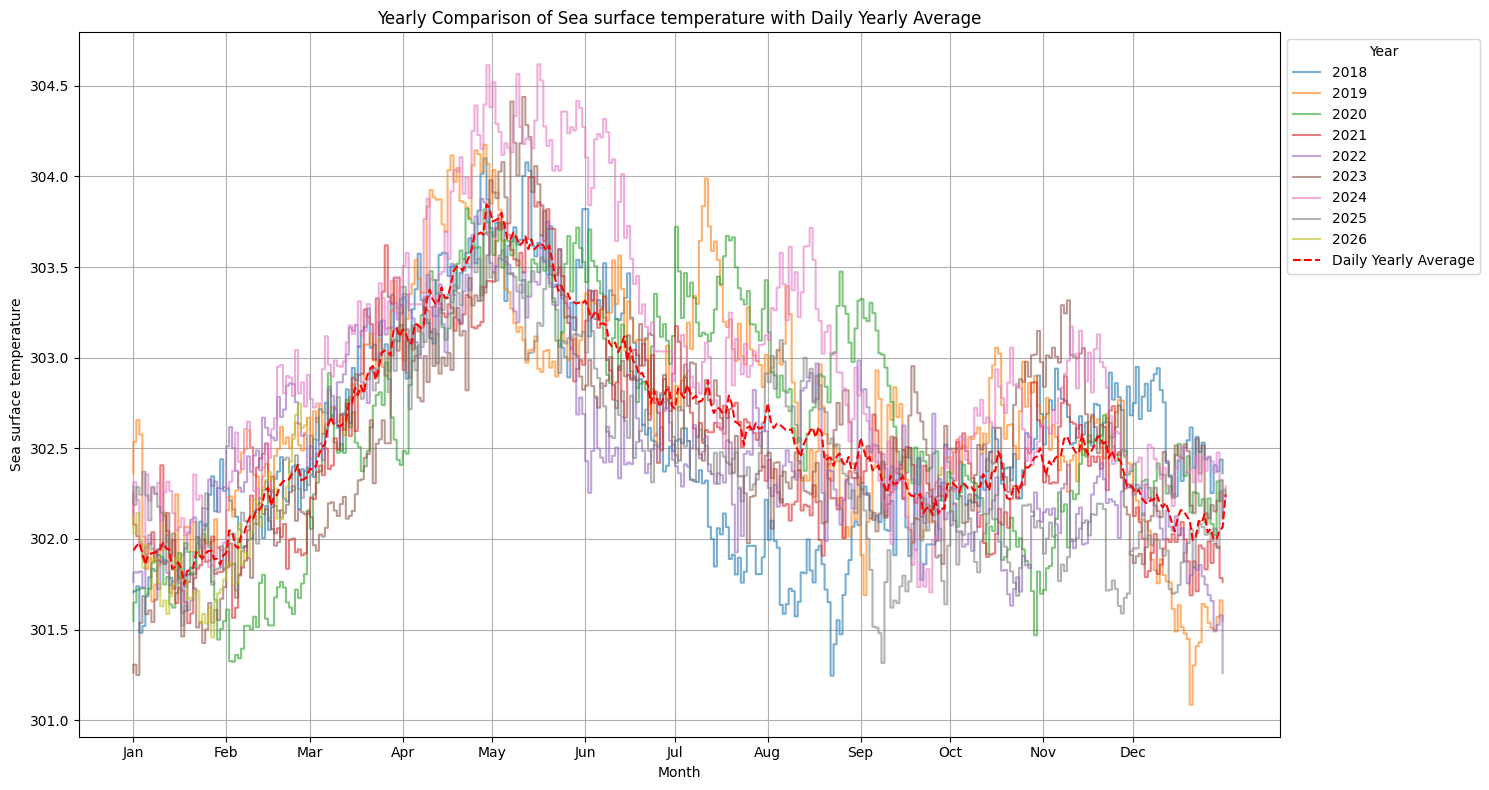

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import numpy as np # Import numpy for calculations

# เลือกคอลัมน์ตัวเลขสำหรับการพล็อต
numerical_cols = PaTongPhuket_indexed.select_dtypes(include=['float64', 'int64']).columns

# Get unique years from the index
years = PaTongPhuket_indexed.index.year.unique()

# Add 'day_of_year' to the original indexed DataFrame for easier calculation of daily average
PaTongPhuket_indexed['day_of_year'] = PaTongPhuket_indexed.index.dayofyear

# Calculate the average for each day of the year across all years
# Group by 'day_of_year' and calculate the mean for each numerical column
daily_yearly_average = PaTongPhuket_indexed.groupby('day_of_year')[numerical_cols].mean()


# พล็อตแต่ละคอลัมน์ตัวเลขแยกกัน โดยให้แต่ละปีเป็นบรรทัดแยกกัน
for col in numerical_cols:
    plt.figure(figsize=(15, 8))

    for year in years:
        # กรองข้อมูลสำหรับปีปัจจุบัน
        data_yearly = PaTongPhuket_indexed[PaTongPhuket_indexed.index.year == year].copy()

        # Plot the data using the day of the year for the x-axis
        plt.plot(data_yearly['day_of_year'], data_yearly[col], label=year, alpha=0.6) # Added alpha for better visibility of individual years

    # Plot the daily yearly average line in red
    # Ensure the index of daily_yearly_average is used for the x-axis
    plt.plot(daily_yearly_average.index, daily_yearly_average[col], color='red', linestyle='--', label=f'Daily Yearly Average')


    plt.title(f'Yearly Comparison of {col} with Daily Yearly Average')
    plt.xlabel('Month') # Change xlabel to Month
    plt.ylabel(col)
    plt.legend(title='Year', loc='upper left', bbox_to_anchor=(1, 1))
    plt.grid(True)

    # Set x-axis major locator and formatter to show months correctly
    ax = plt.gca()
    # Define the positions of the ticks based on the day of the year for the start of each month
    # This is an approximation; for more accuracy, consider leap years and exact days in months
    month_starts_dayofyear = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335] # Approximate start day of year for each month (non-leap year)
    month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

    ax.xaxis.set_major_locator(plt.FixedLocator(month_starts_dayofyear))
    ax.xaxis.set_major_formatter(plt.FixedFormatter(month_names))


    plt.tight_layout()
    plt.show()

ยกตัวอย่างรูปแรก จะเห็นว่าในแต่ละปี เส้นของความสูงคลื่นมีรูปแบบการเปลี่ยนแปลงที่คล้ายคลึงกันมากๆ โดยทั่วไปแล้ว:
- ความสูงคลื่นมักจะ ต่ำ ในช่วงต้นปี (ประมาณ มกราคม - เมษายน)
- ความสูงคลื่นจะเริ่ม สูงขึ้น ในช่วงกลางปี (ประมาณ พฤษภาคม - กันยายน)
- จากนั้นความสูงคลื่นจะเริ่ม ลดลง อีกครั้งในช่วงปลายปี (ประมาณ ตุลาคม - ธันวาคม)
รูปแบบนี้บอกได้ว่าความสูงคลื่นที่ป่าตอง ภูเก็ต มีอิทธิพลจากฤดูกาลอย่างมาก ซึ่งสอดคล้องกับฤดูมรสุมในแถบอันดามันครับ (ช่วงประมาณ พ.ค. - ต.ค.)

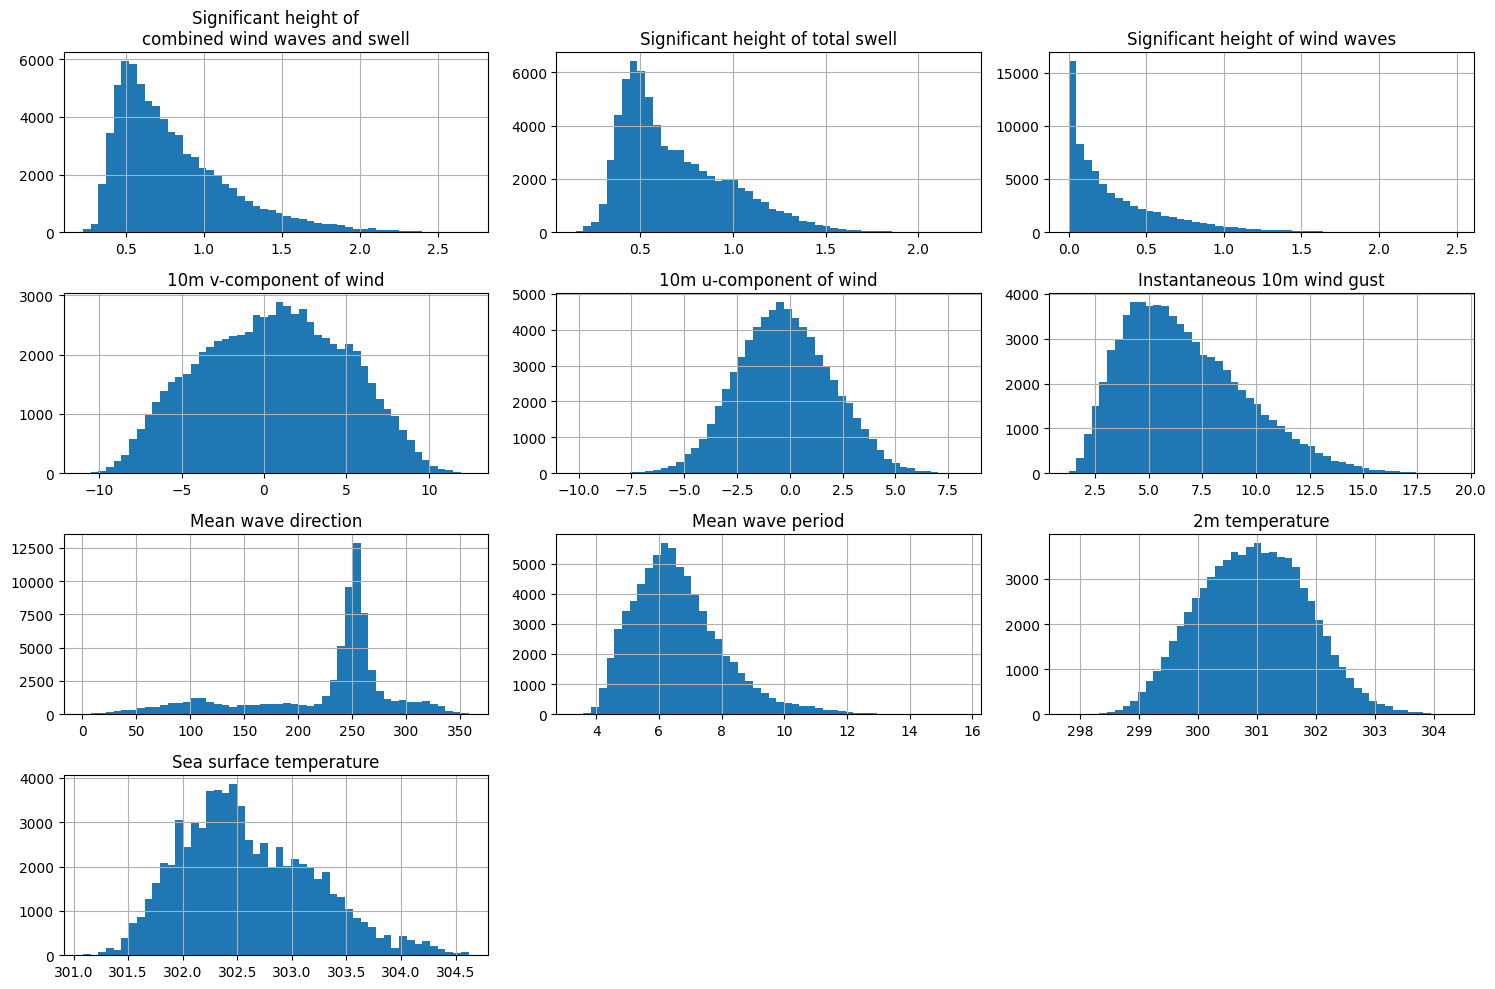

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical columns for plotting distribution
numerical_cols = PaTongPhuket_indexed.select_dtypes(include=['float64', 'int64']).columns

# Plot histograms for numerical columns
PaTongPhuket_indexed[numerical_cols].hist(figsize=(15, 10), bins=50)
plt.tight_layout()
plt.show()

# Alternatively, plot box plots to see distribution and outliers
# fig, axes = plt.subplots(nrows=len(numerical_cols), ncols=1, figsize=(10, len(numerical_cols)*4))
# for i, col in enumerate(numerical_cols):
#     sns.boxplot(x=PaTongPhuket_indexed[col], ax=axes[i])
# plt.tight_layout()
# plt.show()

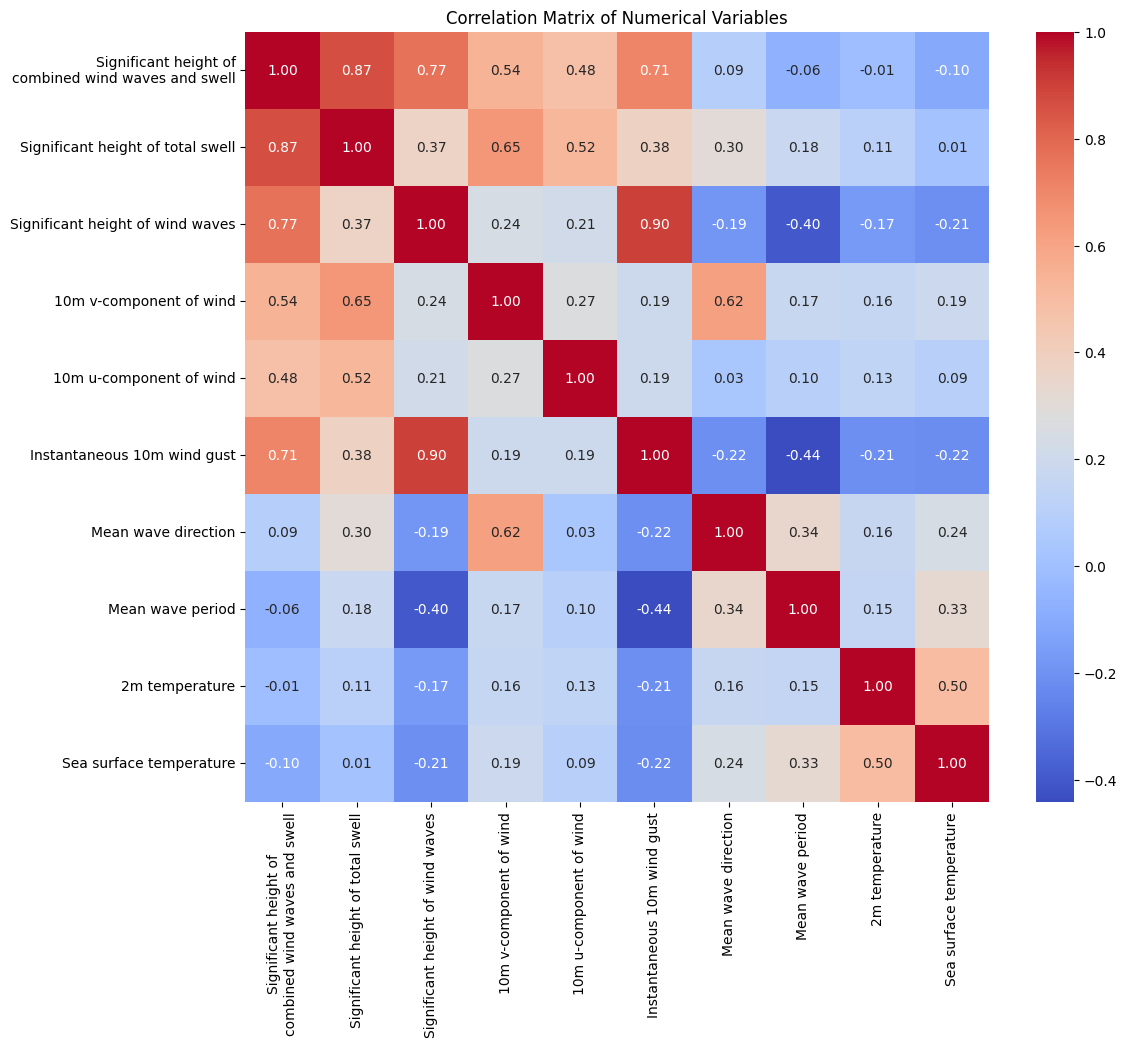

In [ ]:
# Calculate the correlation matrix
correlation_matrix = PaTongPhuket_indexed[numerical_cols].corr()

# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Variables')
plt.show()

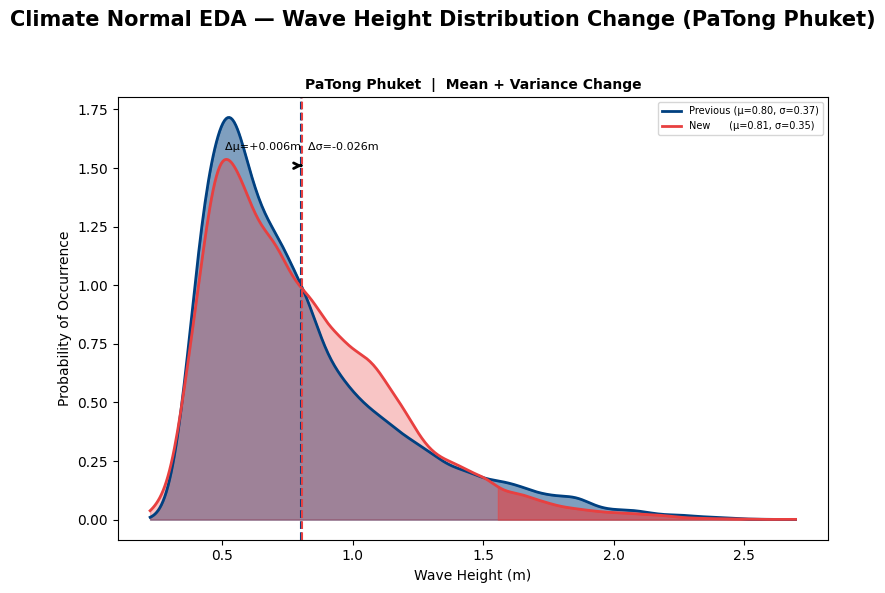

✅ saved /content/drive/MyDrive/Colab_Plots/climate_normal_eda_patong_phuket.png

🔬 Statistical Tests

📍 PaTong Phuket
   t-test : t=-2.063, p=0.0391 → ✅ Mean changed
   Levene : F=10.130, p=0.0015 → ✅ Variance changed
   ➡️  Case (c): Mean AND Variance changed


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
import os
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# Use only Cha-Am data as requested by the user
df_chaam = PaTongPhuket_indexed
name_chaam = 'PaTong Phuket'

# Fix the column name to match the DataFrame (which contains a newline character)
WAVE_COL      = 'Significant height of\ncombined wind waves and swell'
PERIOD1_END   = 2021
PERIOD2_START = 2022

def split_periods(df):
    p1 = df[df.index.year <= PERIOD1_END][WAVE_COL].dropna()
    p2 = df[df.index.year >= PERIOD2_START][WAVE_COL].dropna()
    return p1, p2

colors = {'Previous': '#004080', 'New': '#E84040'}

# Adjusting subplot layout for a single plot
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

fig.suptitle(f"Climate Normal EDA — Wave Height Distribution Change ({name_chaam})",
             fontsize=15, fontweight='bold', y=1.01)

# Define the directory to save the plots in Google Drive
save_dir = '/content/drive/MyDrive/Colab_Plots/'
os.makedirs(save_dir, exist_ok=True)

# Process only the Cha-Am dataframe
p1, p2 = split_periods(df_chaam)

xs   = np.linspace(min(p1.min(), p2.min()), max(p1.max(), p2.max()), 400)
y1   = stats.gaussian_kde(p1)(xs)
y2   = stats.gaussian_kde(p2)(xs)

delta_mean = p2.mean() - p1.mean()
delta_std  = p2.std()  - p1.std()
ymax       = max(y1.max(), y2.max())

ax.fill_between(xs, y1, alpha=0.5, color=colors['Previous'])
ax.fill_between(xs, y2, alpha=0.3, color=colors['New'])
ax.plot(xs, y1, color=colors['Previous'], lw=2,
        label=f'Previous (μ={p1.mean():.2f}, σ={p1.std():.2f})')
ax.plot(xs, y2, color=colors['New'],      lw=2,
        label=f'New      (μ={p2.mean():.2f}, σ={p2.std():.2f})')
ax.axvline(p1.mean(), color=colors['Previous'], lw=1.5, linestyle='--')
ax.axvline(p2.mean(), color=colors['New'],      lw=1.5, linestyle='--')

# Arrow and annotation
arrow_y = ymax * 0.88
ax.annotate('',
    xy=(p2.mean(), arrow_y), xytext=(p1.mean(), arrow_y),
    arrowprops=dict(arrowstyle='->', color='black', lw=2))
ax.text((p1.mean()+p2.mean())/2, arrow_y + ymax*0.04,
        f'Δμ={delta_mean:+.3f}m  Δσ={delta_std:+.3f}m',
        ha='center', fontsize=8)

tail_thresh = p1.mean() + 2 * p1.std()
ax.fill_between(xs, y2, where=(xs >= tail_thresh),
                alpha=0.5, color=colors['New'])
ax.set_title(f"{name_chaam}  |  Mean + Variance Change", fontsize=10, fontweight='bold')
ax.set_xlabel("Wave Height (m)")
ax.set_ylabel("Probability of Occurrence")
ax.legend(fontsize=7, loc='upper right')

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plot_filename = os.path.join(save_dir, f'climate_normal_eda_{name_chaam.lower().replace(" ", "_")}.png')
plt.savefig(plot_filename, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ saved {plot_filename}")

# Statistical Tests
print("\n🔬 Statistical Tests")
print("="*60)

p1, p2 = split_periods(df_chaam)
if len(p1) == 0 or len(p2) == 0:
    print(f"\n📍 {name_chaam} ⚠️ Not enough data")
else:
    t_stat, t_p = stats.ttest_ind(p1, p2)
    l_stat, l_p = stats.levene(p1, p2)
    print(f"\n📍 {name_chaam}")
    print(f"   t-test : t={t_stat:.3f}, p={t_p:.4f} → {'✅ Mean changed' if t_p<0.05 else '➖ No change'}")
    print(f"   Levene : F={l_stat:.3f}, p={l_p:.4f} → {'✅ Variance changed' if l_p<0.05 else '➖ No change'}")
    if   t_p<0.05 and l_p<0.05: print("   ➡️  Case (c): Mean AND Variance changed")
    elif t_p<0.05:               print("   ➡️  Case (a): Mean only")
    elif l_p<0.05:               print("   ➡️  Case (b): Variance only")
    else:                        print("   ➡️  No significant climate shift")

In [ ]:
output_path = "/content/drive/MyDrive/eda_Patong Phuket_1.csv"
PaTongPhuket_indexed.to_csv(output_path)
print(f"DataFrame saved to {output_path}")

DataFrame saved to /content/drive/MyDrive/eda_Patong Phuket_1.csv


ข้อมูล CV  : 2018-01-01 → 2025-12-31 (70128 ชั่วโมง)
ข้อมูล Test: 2026-01-01 → 2026-02-28 (1416 ชั่วโมง)
--------------------------------------------------
--- Fold 1 ---
  Train: 2018-01-01 → 2019-05-02  (11,688 rows)
  Val  : 2019-05-03 → 2020-08-31  (11,688 rows)
--- Fold 2 ---
  Train: 2018-01-01 → 2020-08-31  (23,376 rows)
  Val  : 2020-09-01 → 2021-12-31  (11,688 rows)
--- Fold 3 ---
  Train: 2018-01-01 → 2021-12-31  (35,064 rows)
  Val  : 2022-01-01 → 2023-05-02  (11,688 rows)
--- Fold 4 ---
  Train: 2018-01-01 → 2023-05-02  (46,752 rows)
  Val  : 2023-05-03 → 2024-08-31  (11,688 rows)
--- Fold 5 ---
  Train: 2018-01-01 → 2024-08-31  (58,440 rows)
  Val  : 2024-09-01 → 2025-12-31  (11,688 rows)


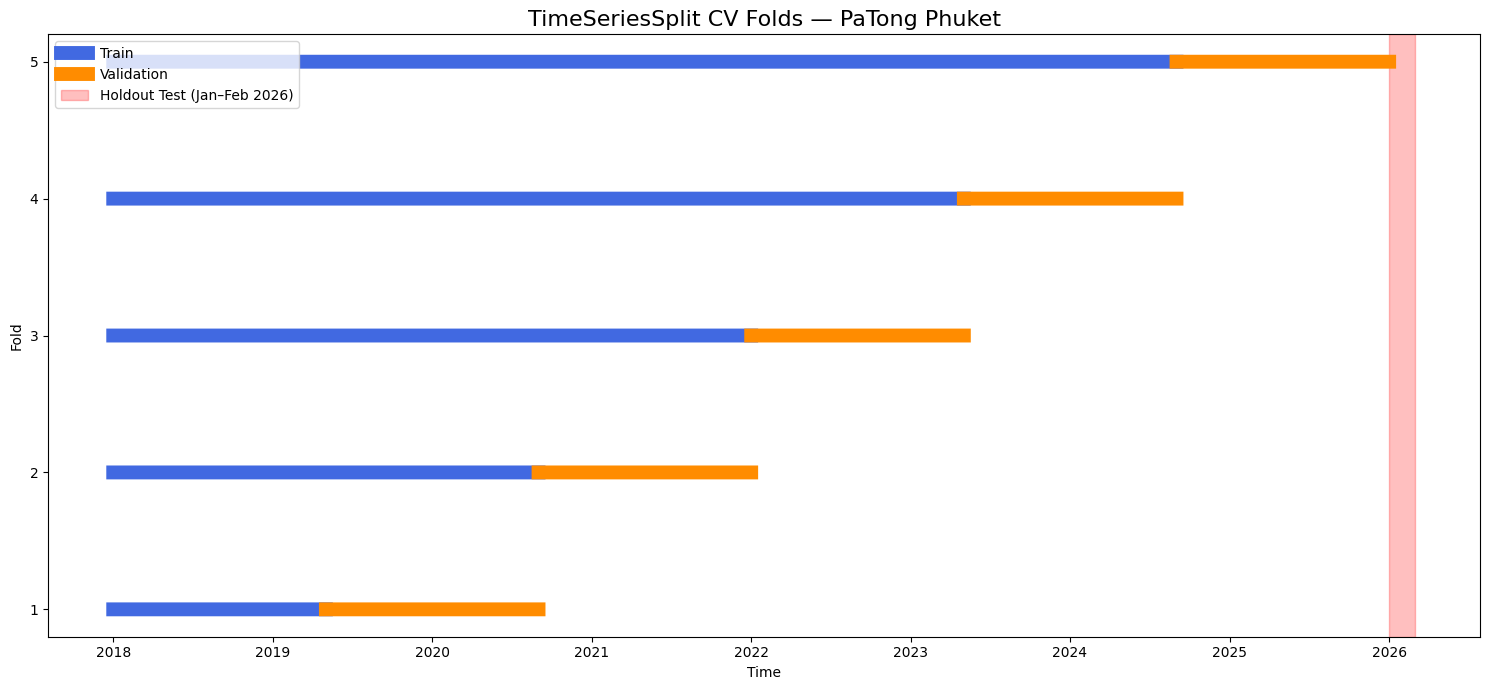

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
import matplotlib.pyplot as plt

# 1. แยก holdout test set ออกก่อนเลย
data_cv   = PaTongPhuket_indexed.loc[:'2025-12-31'].copy()   # ใช้สำหรับ CV ทั้งหมด
data_test = PaTongPhuket_indexed.loc['2026-01-01':'2026-02-28'].copy()  # ห้ามแตะจนกว่าจะพยากรณ์จริง

print(f"ข้อมูล CV  : {data_cv.index.min().date()} → {data_cv.index.max().date()} ({data_cv.shape[0]} ชั่วโมง)")
print(f"ข้อมูล Test: {data_test.index.min().date()} → {data_test.index.max().date()} ({data_test.shape[0]} ชั่วโมง)")
print("-" * 50)

# 2. กำหนด X, y จากข้อมูล CV เท่านั้น
TARGET = 'Significant height of\ncombined wind waves and swell'
y = data_cv[TARGET]
X = data_cv.drop(columns=[TARGET])

# 3. TimeSeriesSplit 5 folds บน data_cv
N_SPLITS = 5
tscv = TimeSeriesSplit(n_splits=N_SPLITS)
split_indices = {}

for fold_num, (train_idx, val_idx) in enumerate(tscv.split(X)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    split_indices[f'fold_{fold_num+1}_train'] = train_idx
    split_indices[f'fold_{fold_num+1}_val']   = val_idx   # ✅ เปลี่ยนชื่อเป็น val ให้ชัดเจน

    print(f"--- Fold {fold_num+1} ---")
    print(f"  Train: {X_train.index.min().date()} → {X_train.index.max().date()}  ({X_train.shape[0]:,} rows)")
    print(f"  Val  : {X_val.index.min().date()} → {X_val.index.max().date()}  ({X_val.shape[0]:,} rows)")

# 4. Visualization
fig, ax = plt.subplots(figsize=(15, 7))

for fold_num, (train_idx, val_idx) in enumerate(tscv.split(X), 1):
    ax.plot(data_cv.index[train_idx], [fold_num]*len(train_idx),
            color='royalblue', lw=10, label='Train' if fold_num == 1 else "")
    ax.plot(data_cv.index[val_idx], [fold_num]*len(val_idx),
            color='darkorange', lw=10, label='Validation' if fold_num == 1 else "")

# แสดง holdout test set ด้วย
ax.axvspan(data_test.index.min(), data_test.index.max(),
           alpha=0.25, color='red', label='Holdout Test (Jan–Feb 2026)')

ax.set_title('TimeSeriesSplit CV Folds — PaTong Phuket', fontsize=16)
ax.set_xlabel('Time')
ax.set_ylabel('Fold')
ax.set_yticks(range(1, N_SPLITS + 1))
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
import pickle
import os

# กำหนด path ใน Google Drive
save_dir = '/content/drive/MyDrive/wave_prediction/data_split_patong'
os.makedirs(save_dir, exist_ok=True)

# รวบรวมทุกอย่างที่ต้องการบันทึก
data_to_save = {
    # ข้อมูล CV (2018-2025)
    'X': X,
    'y': y,

    # ข้อมูล Holdout Test (Jan-Feb 2026)
    'X_test': data_test.drop(columns=[TARGET]),
    'y_test': data_test[TARGET],

    # split indices ของแต่ละ fold
    'split_indices': split_indices,

    # config
    'n_splits': N_SPLITS,
    'target_column': TARGET,
    'tscv': tscv,
}

# บันทึกเป็น pickle
save_path = os.path.join(save_dir, 'data_split_patong.pkl')
with open(save_path, 'wb') as f:
    pickle.dump(data_to_save, f)

print(f"บันทึกสำเร็จ: {save_path}")
print(f"ขนาดไฟล์: {os.path.getsize(save_path) / 1024 / 1024:.2f} MB")
print("\nสิ่งที่บันทึก:")
print(f"  X shape       : {X.shape}")
print(f"  y shape       : {y.shape}")
print(f"  X_test shape  : {data_test.drop(columns=[TARGET]).shape}")
print(f"  y_test shape  : {data_test[TARGET].shape}")
print(f"  N_SPLITS      : {N_SPLITS}")
print(f"  split_indices : {list(split_indices.keys())}")

บันทึกสำเร็จ: /content/drive/MyDrive/wave_prediction/data_split_patong/data_split_patong.pkl
ขนาดไฟล์: 8.61 MB

สิ่งที่บันทึก:
  X shape       : (70128, 10)
  y shape       : (70128,)
  X_test shape  : (1416, 10)
  y_test shape  : (1416,)
  N_SPLITS      : 5
  split_indices : ['fold_1_train', 'fold_1_val', 'fold_2_train', 'fold_2_val', 'fold_3_train', 'fold_3_val', 'fold_4_train', 'fold_4_val', 'fold_5_train', 'fold_5_val']
